# Evaluación Final — Sartorius Cell Instance Segmentation
### 5 modelos | K-Fold (k=5) | Validación + Test
---
**Modelos evaluados:**
| Modelo | Checkpoint | Plataforma |
|---|---|---|
| Cellpose 2.0 | `./cellpose_results/` | Local |
| U-Net++ | `./checkpoints/unetpp_best.pth` | Colab |
| HoVer-Net | `./checkpoints/hovernet_best.pth` | Kaggle |
| Mask R-CNN | `./checkpoints/maskrcnn_best.pth` | Kaggle |
| SAM | `./checkpoints/sam_best.pth` | Colab |

> **Orden de ejecución:**  
> 1. Cargar preprocesamiento → 2. K-Fold con mejor hparams → 3. Métricas completas → 4. Visualizaciones

## 1. Librerías

In [1]:
import os, json, copy, warnings, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import cv2
from PIL import Image
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score,
    roc_curve, precision_recall_curve, auc
)
from scipy.spatial.distance import directed_hausdorff
from sklearn.model_selection import ParameterGrid
import segmentation_models_pytorch as smp
from segment_anything import sam_model_registry

SEED   = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

c:\Users\Hp\miniconda3\envs\ml_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
GPU   : NVIDIA GeForce RTX 4050 Laptop GPU


## 2. Rutas y configuración

In [2]:
# ── Ajustar según tu entorno ─────────────────────────────────
BASE_DIR       = Path('.')
CKPT_DIR       = BASE_DIR / 'checkpoints'
CELLPOSE_DIR   = BASE_DIR / 'cellpose_results'
EXPORT_FILE    = BASE_DIR / 'preprocessing_exports' / 'preprocessing_data.joblib'
OUTPUT_DIR     = BASE_DIR / 'evaluation_results'
OUTPUT_DIR.mkdir(exist_ok=True)
DATA_DIR  = Path(r'C:\Users\Hp\Documents\Deep_learning\Imagenes\sartorius-cell-instance-segmentation')
TRAIN_DIR = DATA_DIR / 'train' 
# Checkpoints por modelo
CKPTS = {
    'unetpp'  : CKPT_DIR / 'unetpp_best.pth',
    'hovernet': CKPT_DIR / 'hovernet_best.pth',
    'maskrcnn': CKPT_DIR / 'maskrcnn_best.pth',
    'sam'     : CKPT_DIR / 'sam_best.pth',
    'sam_pretrained': CKPT_DIR / 'sam_vit_b_01ec64.pth',
    'cellpose': CELLPOSE_DIR / 'cellpose_best_weights.pth',
}

# Verificar disponibilidad
print('Estado de checkpoints:')
for name, path in CKPTS.items():
    exists = path.exists()
    size   = f'{path.stat().st_size/1e6:.1f} MB' if exists else 'NO ENCONTRADO'
    print(f'  {name:<12}: {"OK" if exists else "FALTA"} | {size}')

Estado de checkpoints:
  unetpp      : OK | 55.1 MB
  hovernet    : OK | 391.3 MB
  maskrcnn    : OK | 176.3 MB
  sam         : OK | 375.1 MB
  sam_pretrained: OK | 375.0 MB
  cellpose    : OK | 26.6 MB


## 3. Cargar pipeline de preprocesamiento

In [3]:
import sys
sys.path.insert(0, str(BASE_DIR))
from sartorius_utils import SartoriusDataset as SartoriusDatasetGeneral, preprocess, rle_decode

data = joblib.load(EXPORT_FILE)
df_img        = data['df_img']
df_train_base = data['df_train_base']
df_val        = data['df_val']
df_test       = data['df_test']
folds         = data['folds']
config        = data['config']

IMG_SIZE = config['IMG_SIZE']
print(f'df_train_base : {df_train_base.shape}')
print(f'df_val        : {df_val.shape}')
print(f'df_test       : {df_test.shape}')
print(f'folds K-Fold  : {len(folds)}')
print(f'IMG_SIZE      : {IMG_SIZE}')

df_train_base : (424, 6)
df_val        : (91, 6)
df_test       : (91, 6)
folds K-Fold  : 5
IMG_SIZE      : (512, 512)


## 4. Funciones de métricas completas

In [4]:
def iou_score(pred, true, eps=1e-6):
    pred = pred.bool(); true = true.bool()
    return (((pred & true).float().sum() + eps) /
            ((pred | true).float().sum() + eps)).item()

def dice_score(pred, true, eps=1e-6):
    pred = pred.bool().float(); true = true.bool().float()
    return ((2*(pred*true).sum() + eps) /
            (pred.sum() + true.sum() + eps)).item()

def precision_score_fn(pred, true, eps=1e-6):
    tp = (pred.bool() & true.bool()).float().sum()
    fp = (pred.bool() & ~true.bool()).float().sum()
    return ((tp + eps) / (tp + fp + eps)).item()

def recall_score_fn(pred, true, eps=1e-6):
    tp = (pred.bool() & true.bool()).float().sum()
    fn = (~pred.bool() & true.bool()).float().sum()
    return ((tp + eps) / (tp + fn + eps)).item()

def auc_score(pred_prob, true):
    y_true = true.bool().cpu().numpy().flatten().astype(int)
    y_prob = pred_prob.cpu().numpy().flatten()
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return float(roc_auc_score(y_true, y_prob))

def hausdorff_distance(pred, true):
    pred_pts = np.argwhere(pred.bool().cpu().numpy())
    true_pts = np.argwhere(true.bool().cpu().numpy())
    if len(pred_pts) == 0 or len(true_pts) == 0:
        return float('inf')
    return float(max(
        directed_hausdorff(pred_pts, true_pts)[0],
        directed_hausdorff(true_pts, pred_pts)[0]
    ))

def balanced_accuracy_fn(pred, true):
    return float(balanced_accuracy_score(
        true.bool().cpu().numpy().flatten().astype(int),
        pred.bool().cpu().numpy().flatten().astype(int)
    ))

def compute_all_metrics(pred_prob, true_bin, threshold=0.5):
    """
    Calcula las 7 metricas para un par pred/true.
    pred_prob : tensor (H,W) probabilidades continuas
    true_bin  : tensor (H,W) bool ground truth
    """
    pred_bin = (pred_prob > threshold)
    return {
        'iou'              : iou_score(pred_bin, true_bin),
        'dice'             : dice_score(pred_bin, true_bin),
        'precision'        : precision_score_fn(pred_bin, true_bin),
        'recall'           : recall_score_fn(pred_bin, true_bin),
        'auc'              : auc_score(pred_prob, true_bin),
        'hausdorff'        : hausdorff_distance(pred_bin, true_bin),
        'balanced_accuracy': balanced_accuracy_fn(pred_bin, true_bin),
        'pred_prob'        : pred_prob.cpu().numpy(),
        'pred_bin'         : pred_bin.cpu().numpy(),
        'true_bin'         : true_bin.cpu().numpy(),
    }

def aggregate_metrics(results_list):
    """Media y std de cada metrica sobre una lista de dicts."""
    keys = ['iou','dice','precision','recall','auc','hausdorff','balanced_accuracy']
    agg  = {}
    for k in keys:
        vals  = [r[k] for r in results_list
                 if r[k] != float('inf') and not np.isnan(r[k])]
        agg[k] = {'mean': float(np.mean(vals)) if vals else np.nan,
                  'std' : float(np.std(vals))  if vals else np.nan,
                  'vals': vals}
    return agg

print('Métricas definidas OK')

Métricas definidas OK


## 5. Definición de arquitecturas para cargar checkpoints

In [5]:
# ── U-Net++ ──────────────────────────────────────────────────
def build_unetpp(encoder_name='efficientnet-b3'):  
    return smp.UnetPlusPlus(
        encoder_name=encoder_name, 
        encoder_weights=None,                      
        in_channels=3, 
        classes=1, 
        activation=None
    )

# ── HoVer-Net ─────────────────────────────────────────────────
import math
class HoVerNet(nn.Module):
    def __init__(self, encoder_name='resnet50', num_classes=3):
        super().__init__()
        self.np_branch = smp.Unet(encoder_name=encoder_name,
            encoder_weights=None, in_channels=3, classes=1, activation=None)
        self.hv_branch = smp.Unet(encoder_name=encoder_name,
            encoder_weights=None, in_channels=3, classes=2, activation=None)
        self.nc_branch = smp.Unet(encoder_name=encoder_name,
            encoder_weights=None, in_channels=3, classes=num_classes, activation=None)
    def forward(self, x):
        return self.np_branch(x), self.hv_branch(x), self.nc_branch(x)

# ── Mask R-CNN ────────────────────────────────────────────────
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# Asegúrate de pasar el num_classes correcto dinámicamente o que coincida con el de entrenamiento
def build_maskrcnn_eval(num_classes=4, cfg=None):
    model = maskrcnn_resnet50_fpn(weights=None)
    in_f  = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes)
    in_fm = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_fm, 256, num_classes)
    if cfg is not None:
        model.roi_heads.score_thresh       = cfg.get('score_thresh', 0.2)
        model.roi_heads.nms_thresh         = cfg.get('nms_thresh', 0.5)
    else:
        model.roi_heads.score_thresh       = 0.2  
        model.roi_heads.nms_thresh         = 0.3  
        
    model.roi_heads.detections_per_img = 600
    
    return model

def load_model(name, device=DEVICE):
    path = CKPTS[name]
    if not path.exists():
        print(f'  SKIP {name}: checkpoint no encontrado')
        return None

    if name == 'unetpp':
        model = build_unetpp()
        state = torch.load(path, map_location='cpu')
        if 'model_state_dict' in state: state = state['model_state_dict']
        if 'state' in state: state = state['state']   # ← formato CheckpointManager
        model.load_state_dict(state)
        model.eval().to(device)

    elif name == 'hovernet':
        model = HoVerNet()
        state = torch.load(path, map_location='cpu')
        if 'model_state_dict' in state: state = state['model_state_dict']
        if 'state' in state: state = state['state']
        model.load_state_dict(state)
        model.eval().to(device)

    elif name == 'maskrcnn':
        model = build_maskrcnn_eval(num_classes=4)
        state = torch.load(path, map_location='cpu')
        if 'state' in state: state = state['state']
        model.load_state_dict(state)
        model.eval().to(device)

    elif name == 'sam':
        sam_pretrained = CKPTS['sam_pretrained']
        sam_finetuned  = CKPTS['sam']

        if not sam_pretrained.exists():
            print(f'  SKIP SAM: checkpoint pretrained no encontrado en {sam_pretrained}')
            return None

        # Cargar arquitectura base
        model = sam_model_registry['vit_b'](checkpoint=str(sam_pretrained))

        # Cargar pesos fine-tuneados del decoder si existen
        if sam_finetuned.exists():
            state = torch.load(sam_finetuned, map_location='cpu')
            if 'state' in state: state = state['state']
            # SAM fine-tuning solo entrena mask_decoder + prompt_encoder
            # strict=False para ignorar keys del image_encoder congelado
            model.load_state_dict(state, strict=False)
            print(f'  Decoder fine-tuneado cargado: {sam_finetuned.name}')
        else:
            print(f'  AVISO: usando SAM sin fine-tuning (solo pretrained)')

        model.eval().to(device)

    elif name == 'cellpose':
        from cellpose import models as cp_models

        hparams_path = CELLPOSE_DIR / 'best_hparams.json'
        if not hparams_path.exists():
            print(f'  SKIP cellpose: best_hparams.json no encontrado en {hparams_path}')
            return None, {}

        with open(hparams_path) as f:
            hparams = json.load(f)

        model = cp_models.CellposeModel(
            gpu=torch.cuda.is_available(),
            model_type=hparams.get('model_type', 'cyto2')
        )

        if path.exists():
            model.net.load_state_dict(torch.load(path, map_location='cpu'))
            print(f'  Cargado: {path.name} ({path.stat().st_size/1e6:.1f} MB)')
        else:
            print(f'  AVISO: pesos no encontrados — usando modelo base {hparams.get("model_type")}')

        return model, hparams  # retorna tupla — distinto al resto de modelos 

    sz = path.stat().st_size / 1e6
    print(f'  Cargado: {path.name} ({sz:.1f} MB)')
    return model

print('Arquitecturas definidas OK')

Arquitecturas definidas OK


## 6. Collate functions y DataLoaders

In [6]:
CELL_TYPE_MAP = {
    'shsy5y': 1,
    'astro':  2,
    'cort':   3
}
class SartoriusDatasetMRCNN(Dataset):
    """Dataset específico para Mask R-CNN — mismo que se usó en entrenamiento."""
    def __init__(self, df, img_dir, img_size=512, augment=False):
        self.df       = df
        self.img_dir  = Path(img_dir)
        self.img_size = img_size
        self.augment  = augment
        self.ids = df['id_imagen'].unique().tolist()

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        rows = self.df[self.df['id_imagen'] == img_id]
        img    = np.array(
            Image.open(self.img_dir / f'{img_id}.png').convert('RGB')
        )
        h0, w0 = img.shape[:2]
        img = cv2.resize(img, self.img_size)
        img_tensor = torch.from_numpy(
            img.transpose(2, 0, 1)
        ).float() / 255.0
        masks, boxes, labels = [], [], []
        for _, row in rows.iterrows():

            for rle in row['rles']:

                mask = rle_decode(rle, shape=(h0, w0))

                mask = cv2.resize(
                        mask,
                        self.img_size,
                        interpolation=cv2.INTER_NEAREST
                )

                if mask.sum() == 0:
                    continue

                masks.append(mask)

                ys, xs = np.where(mask)

                boxes.append([
                    xs.min(),
                    ys.min(),
                    xs.max(),
                    ys.max()
                ])

                labels.append(
                    CELL_TYPE_MAP.get(row['cell_type'], 1)
                )
        if len(masks) == 0:
            return img_tensor, {
                'boxes'   : torch.zeros((0, 4), dtype=torch.float32),
                'labels'  : torch.zeros(0, dtype=torch.int64),
                'masks'   : torch.zeros((0, *self.img_size),
                                        dtype=torch.uint8),
                'image_id': torch.tensor([idx]),
                'area'    : torch.zeros(0, dtype=torch.float32),
                'iscrowd' : torch.zeros(0, dtype=torch.int64),
            }
        boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
        area    = ((boxes_t[:,3]-boxes_t[:,1]) * (boxes_t[:,2]-boxes_t[:,0]))
        return img_tensor, {
            'boxes'   : boxes_t,
            'labels'  : torch.as_tensor(labels, dtype=torch.int64),
            'masks'   : torch.as_tensor(np.stack(masks), dtype=torch.uint8),
            'image_id': torch.tensor([idx]),
            'area'    : area,
            'iscrowd' : torch.zeros(len(labels), dtype=torch.int64),
        }
def collate_fn_binary(batch):
    """Colapsa mascaras a binario (B,1,H,W). Para U-Net++"""
    images = torch.stack([item['image'] for item in batch])
    masks  = torch.stack([
        (item['masks'].sum(0, keepdim=True) > 0).float() for item in batch
    ])
    meta = [item['meta'] for item in batch]
    return {'image': images, 'masks': masks, 'meta': meta}

def collate_fn_instance(batch):
    """Mantiene instancias con padding. Para HoVer-Net."""
    images = torch.stack([item['image'] for item in batch])
    max_n  = max(item['masks'].shape[0] for item in batch)
    padded = []
    for item in batch:
        m   = item['masks']
        pad = max_n - m.shape[0]
        if pad > 0:
            m = torch.cat([m, torch.zeros(pad,*m.shape[1:], dtype=m.dtype)])
        padded.append(m)
    return {'image': images, 'masks': torch.stack(padded),
            'meta': [item['meta'] for item in batch]}
def collate_fn_mrcnn(batch):
    return tuple(zip(*batch))
def collate_sam(batch):
    """
    Collate para SAM.
    - image_sam: resize a 1024×1024 precalculado, apilable
    - masks: lista (N variable por imagen, no se puede apilar)
    """
    return {
        'image'    : torch.stack([b['image'] for b in batch]),
        'image_sam': torch.stack([
            nn.functional.interpolate(
                b['image'].unsqueeze(0) * 255,
                size=(1024, 1024), mode='bilinear', align_corners=False
            ).squeeze(0).clamp(0, 255)
            for b in batch
        ]),
        'masks': [b['masks'] for b in batch],
        'meta' : [b['meta'] for b in batch],
    }
def make_eval_loader(df, collate_fn, batch_size=4, for_mrcnn=False):
    if for_mrcnn:
        ds = SartoriusDatasetMRCNN(
            df,
            img_dir  = TRAIN_DIR,
            img_size = IMG_SIZE,
            augment  = False
        )
        return DataLoader(ds, batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=True,
                          collate_fn=collate_fn_mrcnn)
    else:
        ds = SartoriusDatasetGeneral(df, is_train=False)
        return DataLoader(ds, batch_size=batch_size, shuffle=False,
                          num_workers=0, pin_memory=True,
                          collate_fn=collate_fn)
print('Collate functions definidas OK')

Collate functions definidas OK


## 7. Función de evaluación genérica

In [7]:
@torch.inference_mode()
def evaluate_model(model, loader, model_name, device=DEVICE,
                   threshold=0.5, is_maskrcnn=False,
                   is_hovernet=False, is_sam=False):   
    model.eval()
    results  = []
    all_probs, all_trues = [], []

    for batch in tqdm(loader, desc=f'  {model_name}', leave=False):

        # ── Mask R-CNN ────────────────────────────────────────────────────
        if is_maskrcnn:
            # tuple(zip(*batch)) retorna ((img1, img2,...), (tgt1, tgt2,...))
            # NO itera imagen-por-imagen — desempacar directamente:
            images_tuple, targets_tuple = batch
            images  = [img.to(device) for img in images_tuple]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets_tuple]
            preds   = model(images)

            for pred, tgt in zip(preds, targets_tuple):
                if len(pred['masks']) == 0:
                    H, W = IMG_SIZE, IMG_SIZE
                    pred_prob = torch.zeros(H, W)
                else:
                    scores     = pred['scores'].cpu()
                    masks_inst = pred['masks'][:, 0].cpu()
                    pred_prob  = (masks_inst * scores[:, None, None]).max(0).values.float()

                gt_masks = tgt['masks']
                true_bin = (gt_masks.sum(0) > 0).bool() \
                   if gt_masks.numel() > 0 \
                   else torch.zeros(pred_prob.shape, dtype=torch.bool)

                m = compute_all_metrics(pred_prob, true_bin, threshold)
                results.append(m)
                all_probs.append(pred_prob.flatten().numpy())
                all_trues.append(true_bin.flatten().numpy().astype(int))

        # ── SAM ───────────────────────────────────────────────────────────
        elif is_sam:

            images_512 = batch['image'].to(device)

            masks = torch.stack([
                (m.sum(0, keepdim=True) > 0).float()
                for m in batch['masks']
            ])

            # Resize a 1024 para encoder SAM
            images_sam = nn.functional.interpolate(
                images_512 * 255,
                size=(1024, 1024),
                mode='bilinear',
                align_corners=False
            ).clamp(0, 255)

            emb = model.image_encoder(images_sam)

            sp, dp = model.prompt_encoder(
                points=None,
                boxes=None,
                masks=None
            )

            pred_out, _ = model.mask_decoder(
                image_embeddings=emb,
                image_pe=model.prompt_encoder.get_dense_pe(),
                sparse_prompt_embeddings=sp,
                dense_prompt_embeddings=dp,
                multimask_output=False,
            )

            pred_probs_batch =  pred_out.squeeze(1).cpu()

            # Resize de vuelta a tamaño original
            pred_probs_batch = nn.functional.interpolate(
                pred_probs_batch.unsqueeze(1),
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            ).squeeze(1)

            true_bins_batch = masks.squeeze(1).bool().cpu()

            for p_prob, t_bin in zip(
                pred_probs_batch,
                true_bins_batch
            ):

                m = compute_all_metrics(
                        p_prob,
                        t_bin,
                        threshold
                    )

                results.append(m)

                all_probs.append(
                    p_prob.flatten().numpy()
                )

                all_trues.append(
                    t_bin.flatten().numpy().astype(int)
                )

        # ── HoVer-Net ─────────────────────────────────────────────────────
        elif is_hovernet:
            images = batch['image'].to(device)
            masks  = batch['masks']
            np_out, _, _ = model(images)
            pred_probs_batch = torch.sigmoid(np_out).squeeze(1).cpu()
            true_bins_batch  = (masks.sum(1) > 0).bool().cpu()

            for p_prob, t_bin in zip(pred_probs_batch, true_bins_batch):
                m = compute_all_metrics(p_prob, t_bin, threshold)
                results.append(m)
                all_probs.append(p_prob.flatten().numpy())
                all_trues.append(t_bin.flatten().numpy().astype(int))
        # ── U-Net++ / genérico ────────────────────────────────────────────
        else:
            images = batch['image'].to(device)
            masks  = batch['masks']
            out    = model(images)
            pred_probs_batch = torch.sigmoid(out).squeeze(1).cpu()
            true_bins_batch  = masks.squeeze(1).bool().cpu()

            for p_prob, t_bin in zip(pred_probs_batch, true_bins_batch):
                m = compute_all_metrics(p_prob, t_bin, threshold)
                results.append(m)
                all_probs.append(p_prob.flatten().numpy())
                all_trues.append(t_bin.flatten().numpy().astype(int))

    return results, np.concatenate(all_probs), np.concatenate(all_trues)
def evaluate_cellpose(model, hparams, df, threshold=0.5):
    """
    Evaluación de Cellpose usando su API propia.
    No usa DataLoader — itera imagen por imagen.

    Parámetros:
        model   : CellposeModel ya cargado
        hparams : dict con los mejores hiperparámetros guardados
        df      : DataFrame con columnas ruta_imagen, rles, height, width
        threshold: umbral de binarización (para métricas)
    """
    img_size = hparams.get('img_size', 512)
    results  = []
    all_probs, all_trues = [], []

    for _, row in tqdm(df.iterrows(), total=len(df),
                       desc='  Cellpose', leave=False):

        # ── Cargar imagen ─────────────────────────────────────────────────
        img_path = str(row['ruta_imagen'])
        img_bgr  = cv2.imread(img_path)
        if img_bgr is None:
            print(f'  AVISO: no se pudo leer {img_path}')
            continue
        img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))

        # ── Inferencia Cellpose ───────────────────────────────────────────
        eval_result = model.eval(
            [img],
            diameter           = hparams.get('diameter'),
            channels           = hparams.get('chan', [0, 0]),
            flow_threshold     = hparams.get('flow_threshold', 0.4),
            cellprob_threshold = hparams.get('cellprob_threshold', 0.0)
        )
        masks_pred = eval_result[0]   # lista de máscaras de instancias
        flows      = eval_result[1]   # flows[2] = probabilidad de célula

        # ── Probabilidad continua ─────────────────────────────────────────
        pred_bin_np = (masks_pred[0] > 0).astype(np.uint8)
        try:
            pred_prob_np = flows[2].copy()
            p_min, p_max = pred_prob_np.min(), pred_prob_np.max()
            pred_prob_np = (pred_prob_np - p_min) / (p_max - p_min + 1e-6)
        except Exception:
            # Si flows[2] no está disponible usar máscara binaria como prob
            pred_prob_np = pred_bin_np.astype(np.float32)

        # ── Ground Truth ──────────────────────────────────────────────────
        rles = row['rles']
        if not isinstance(rles, (list, np.ndarray)):
            continue
        true_list = [
            rle_decode(r, (int(row['height']), int(row['width'])))
            for r in rles if not pd.isna(r)
        ]
        if not true_list:
            continue

        true_bin_np = np.stack(true_list).max(0)
        true_bin_np = cv2.resize(
            true_bin_np.astype(np.uint8),
            (img_size, img_size),
            interpolation=cv2.INTER_NEAREST
        )

        # ── Convertir a tensores ──────────────────────────────────────────
        pred_prob = torch.from_numpy(pred_prob_np.astype(np.float32))
        true_bin  = torch.from_numpy(true_bin_np).bool()

        m = compute_all_metrics(pred_prob, true_bin, threshold)
        results.append(m)
        all_probs.append(pred_prob.flatten().numpy())
        all_trues.append(true_bin.flatten().numpy().astype(int))

    if not results:
        print('  AVISO: evaluate_cellpose no produjo resultados')
        return [], np.array([]), np.array([])

    return results, np.concatenate(all_probs), np.concatenate(all_trues)
print('Funciones de evaluacion definidas OK')

Funciones de evaluacion definidas OK


## 8. Validación cruzada K-Fold (k=5)

**Justificación:** el K-Fold se aplica aquí, con el mejor modelo ya entrenado,
para estimar la varianza real del modelo sobre distintas particiones del dataset.
No se usó durante el grid search por eficiencia computacional
(5 folds × N combinaciones × 50 épocas sería inviable en Colab/Kaggle).

Cada fold reutiliza los **pesos del mejor modelo entrenado** — no reentrena.
El objetivo es medir estabilidad, no buscar hiperparámetros.

In [9]:
def run_kfold_evaluation(model_name, model, folds, df_img,
                          collate_fn,
                          is_hovernet=False,
                          is_maskrcnn=False,
                          is_sam=False,
                          is_cellpose=False,
                          threshold=0.5):

    fold_results = []

    for fold in folds:

        print(f'  Fold {fold["fold"]+1}/5...')

        df_fold_val = df_img[df_img['id_imagen'].isin(fold['val_ids'])]

        # ── Loader especial Mask R-CNN ──
        if is_maskrcnn:

            loader = make_eval_loader(
                df_fold_val,
                collate_fn=None,
                batch_size=2,
                for_mrcnn=True
            )

        # ── Loader SAM ──
        elif is_sam:

            loader = DataLoader(
                SartoriusDatasetGeneral(df_fold_val, is_train=False),
                batch_size=2,
                shuffle=False,
                num_workers=0,
                collate_fn=collate_sam
            )

        # ── Loader Cellpose (NO necesita DataLoader) ──
        elif is_cellpose:

            loader = None

        # ── Loader normal ──
        else:

            loader = make_eval_loader(
                df_fold_val,
                collate_fn,
                batch_size=1
            )

        # ── Evaluación ──
        if is_cellpose:

            results, _, _ = evaluate_model(
                model,
                df_fold_val,
                model_name,
                is_cellpose=True,
                threshold=threshold
            )

        else:

            results, _, _ = evaluate_model(
                model,
                loader,
                model_name,
                is_hovernet=is_hovernet,
                is_maskrcnn=is_maskrcnn,
                is_sam=is_sam,
                threshold=threshold
            )

        agg = aggregate_metrics(results)

        fold_results.append({
            'fold': fold['fold'],
            'metrics': {
                k: v['mean']
                for k, v in agg.items()
            }
        })

        print(
            f'    IoU={agg["iou"]["mean"]:.4f} | '
            f'Dice={agg["dice"]["mean"]:.4f}'
        )

    # ── Resumen ──
    keys = [
        'iou','dice','precision','recall',
        'auc','hausdorff','balanced_accuracy'
    ]

    summary = {}

    for k in keys:

        vals = [
            f['metrics'][k]
            for f in fold_results
            if not np.isnan(f['metrics'][k])
        ]

        summary[k] = {
            'mean': np.mean(vals),
            'std': np.std(vals)
        }

    print(f'\n  K-Fold {model_name}:')

    for k, v in summary.items():
        print(f'    {k:<20}: {v["mean"]:.4f} ± {v["std"]:.4f}')

    return fold_results, summary


kfold_results = {}

# ── U-Net++ ───────────────────────────────────────────────────────────────
print('=== K-Fold U-Net++ ===')
model_up = load_model('unetpp')
if model_up:
    kfold_results['unetpp'], kfold_results['unetpp_summary'] = run_kfold_evaluation(
        'U-Net++',
        model_up,
        folds,
        df_img,
        collate_fn_binary
    )

# ── HoVer-Net ─────────────────────────────────────────────────────────────
print('\n=== K-Fold HoVer-Net ===')
model_hv = load_model('hovernet')
if model_hv:
    kfold_results['hovernet'], kfold_results['hovernet_summary'] = run_kfold_evaluation(
        'HoVer-Net',
        model_hv,
        folds,
        df_img,
        collate_fn_instance,
        is_hovernet=True,
        threshold=0.15
    )
# ── Mask R-CNN ────────────────────────────────────────────────────────────
print('\n=== K-Fold Mask R-CNN ===')

model_mrcnn = load_model('maskrcnn')

if model_mrcnn:
    kfold_results['maskrcnn'], kfold_results['maskrcnn_summary'] = run_kfold_evaluation(
        'Mask R-CNN',
        model_mrcnn,
        folds,
        df_img,
        collate_fn=collate_fn_mrcnn,
        is_maskrcnn=True,
        threshold=0.5
    )

# ── SAM ───────────────────────────────────────────────────────────────────
print('\n=== K-Fold SAM ===')

model_sam = load_model('sam')

if model_sam:
    kfold_results['sam'], kfold_results['sam_summary'] = run_kfold_evaluation(
        'SAM',
        model_sam,
        folds,
        df_img,
        collate_fn=None,
        is_sam=True,
        threshold=0.5
    )

# ── Cargar Cellpose ───────────────────────────────────────────────────────
print('=== Cargando Cellpose ===')
cp_result  = load_model('cellpose')
model_cp   = cp_result[0] if cp_result else None
cp_hparams = cp_result[1] if cp_result else {}

# ── Verificar columnas necesarias para evaluate_cellpose ─────────────────
print('\nColumnas de df_img:', df_img.columns.tolist())
COLS_NECESARIAS = ['id_imagen', 'ruta_imagen', 'rles', 'height', 'width', 'cell_type']
faltantes = [c for c in COLS_NECESARIAS if c not in df_img.columns]
if faltantes:
    print(f'AVISO: columnas faltantes en df_img: {faltantes}')
    print('Cellpose no podrá evaluarse hasta que estas columnas estén disponibles.')
    print('Verifica la exportación en 02_preprocesamiento_sartorius.ipynb')
else:
    print('Columnas OK — df_img compatible con evaluate_cellpose')
# ── Cellpose ──────────────────────────────────────────────────────────────
print('\n=== K-Fold Cellpose ===')

if model_cp and not faltantes:
    cellpose_fold_results = []

    for fold in folds:
        print(f'  Fold {fold["fold"]+1}/5...')
        df_fold_val = df_img[df_img['id_imagen'].isin(fold['val_ids'])]

        # FIX: llamar evaluate_cellpose directamente, sin DataLoader
        results, _, _ = evaluate_cellpose(
            model_cp, cp_hparams, df_fold_val,
            threshold=0.5
        )

        if not results:
            print(f'    Sin resultados en fold {fold["fold"]+1}')
            continue

        agg = aggregate_metrics(results)
        cellpose_fold_results.append({
            'fold'   : fold['fold'],
            'metrics': {k: v['mean'] for k, v in agg.items()}
        })
        print(
            f'    IoU={agg["iou"]["mean"]:.4f} | '
            f'Dice={agg["dice"]["mean"]:.4f}'
        )

    # ── Resumen K-Fold Cellpose ───────────────────────────────────────────
    keys = ['iou','dice','precision','recall',
            'auc','hausdorff','balanced_accuracy']
    cellpose_summary = {}
    for k in keys:
        vals = [
            f['metrics'][k]
            for f in cellpose_fold_results
            if k in f['metrics'] and not np.isnan(f['metrics'][k])
        ]
        cellpose_summary[k] = {
            'mean': float(np.mean(vals)) if vals else float('nan'),
            'std' : float(np.std(vals))  if vals else float('nan'),
        }

    print('\n  K-Fold Cellpose:')
    for k, v in cellpose_summary.items():
        print(f'    {k:<20}: {v["mean"]:.4f} ± {v["std"]:.4f}')

    kfold_results['cellpose']         = cellpose_fold_results
    kfold_results['cellpose_summary'] = cellpose_summary

elif not model_cp:
    print('  SKIP — modelo no cargado')
else:
    print('  SKIP — columnas faltantes en df_img')

print('\nK-Fold completado')

=== K-Fold U-Net++ ===
  Cargado: unetpp_best.pth (55.1 MB)
  Fold 1/5...


    IoU=0.6403 | Dice=0.7736
  Fold 2/5...


    IoU=0.6692 | Dice=0.7974
  Fold 3/5...


    IoU=0.6416 | Dice=0.7751
  Fold 4/5...


    IoU=0.6442 | Dice=0.7762
  Fold 5/5...


...

    IoU=0.1173 | Dice=0.1852
  Fold 2/5...


    IoU=0.1036 | Dice=0.1685
  Fold 3/5...


    IoU=0.1100 | Dice=0.1751
  Fold 4/5...


    IoU=0.1076 | Dice=0.1718
  Fold 5/5...


    IoU=0.1044 | Dice=0.1695

  K-Fold Cellpose:
    iou                 : 0.1086 ± 0.0049
    dice                : 0.1740 ± 0.0060
    precision           : 0.2638 ± 0.0054
    recall              : 0.1615 ± 0.0066
    auc                 : 0.5301 ± 0.0056
    hausdorff           : 151.8797 ± 9.5944
    balanced_accuracy   : 0.5301 ± 0.0056

K-Fold completado


## 9. Evaluación final en Test (15%)

> **Se ejecuta UNA sola vez con el mejor modelo de cada arquitectura.**  
> El conjunto test no se tocó durante el entrenamiento ni el grid search.

In [10]:
test_results = {}
test_probs   = {}
test_trues   = {}

# Cell 18 — threshold por modelo
THRESHOLDS = {
    'unetpp'  : 0.5,
    'hovernet': 0.15,   
    'maskrcnn': 0.5,
    'cellpose': 0.5,
    'sam'     : 0.5,
}

# ── U-Net++ ──────────────────────────────────────────────────
if model_up:
    print('Evaluando U-Net++ en test...')
    loader_test_up = make_eval_loader(df_test, collate_fn_binary)
    res, probs, trues = evaluate_model(
        model_up, loader_test_up, 'U-Net++', threshold=THRESHOLDS['unetpp'])
    test_results['unetpp'] = aggregate_metrics(res)
    test_probs['unetpp']   = probs
    test_trues['unetpp']   = trues
    test_results['unetpp']['raw'] = res

# ── HoVer-Net ────────────────────────────────────────────────
if model_hv:
    print('Evaluando HoVer-Net en test...')
    loader_test_hv = make_eval_loader(df_test, collate_fn_instance,batch_size=2)
    res, probs, trues = evaluate_model(
        model_hv, loader_test_hv, 'HoVer-Net',is_hovernet=True, threshold=THRESHOLDS['hovernet'])
    test_results['hovernet'] = aggregate_metrics(res)
    test_probs['hovernet']   = probs
    test_trues['hovernet']   = trues
    test_results['hovernet']['raw'] = res

# ── Mask R-CNN ───────────────────────────────────────────────
if model_mrcnn:
    print('Evaluando Mask R-CNN en test...')
    loader_test_mrcnn = make_eval_loader(
    df_test, collate_fn=None, batch_size=2, for_mrcnn=True
    )
    res, probs, trues = evaluate_model(
        model_mrcnn, loader_test_mrcnn, 'Mask R-CNN',
        is_maskrcnn=True, threshold=THRESHOLDS['maskrcnn'])
    test_results['maskrcnn'] = aggregate_metrics(res)
    test_probs['maskrcnn']   = probs
    test_trues['maskrcnn']   = trues
    test_results['maskrcnn']['raw'] = res
# ── SAM ─────────────────────────────────────────────────
if model_sam:
    print('Evaluando SAM en test...')
    loader_test_sam = DataLoader(
        SartoriusDatasetGeneral(df_test, is_train=False),
        batch_size=2, shuffle=False, num_workers=0,
        collate_fn=collate_sam
    )
    res, probs, trues = evaluate_model(
    model_sam, loader_test_sam, 'SAM',
    is_sam=True, threshold=THRESHOLDS['sam']
    )
    test_results['sam'] = aggregate_metrics(res)
    test_probs['sam']   = probs
    test_trues['sam']   = trues
    test_results['sam']['raw'] = res
# ── Cellpose ──────────────────────────────────────────────────────────────
if model_cp and not faltantes:
    print('Evaluando Cellpose en test...')

    # FIX: llamar evaluate_cellpose directamente, sin DataLoader
    res, probs, trues = evaluate_cellpose(
        model_cp, cp_hparams, df_test,
        threshold=THRESHOLDS['cellpose']
    )

    if res:
        test_results['cellpose'] = aggregate_metrics(res)
        test_probs['cellpose']   = probs
        test_trues['cellpose']   = trues
        test_results['cellpose']['raw'] = res
        print(
            f'  IoU={test_results["cellpose"]["iou"]["mean"]:.4f} | '
            f'Dice={test_results["cellpose"]["dice"]["mean"]:.4f}'
        )
    else:
        print('  AVISO: sin resultados en test para Cellpose')
elif not model_cp:
    print('Cellpose SKIP — modelo no cargado')
else:
    print('Cellpose SKIP — columnas faltantes en df_img')
print('\n=== RESULTADOS TEST ===')
metrics_k = ['iou','dice','precision','recall','auc','balanced_accuracy']
for name, agg in test_results.items():
    print(f'\n{name}:')
    for k in metrics_k:
        if k in agg:
            print(f'  {k:<20}: {agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}')

Evaluando U-Net++ en test...


Evaluando HoVer-Net en test...


Evaluando Mask R-CNN en test...


Evaluando SAM en test...


Evaluando Cellpose en test...


  IoU=0.1054 | Dice=0.1698

=== RESULTADOS TEST ===

unetpp:
  iou                 : 0.6103 ± 0.1473
  dice                : 0.7453 ± 0.1400
  precision           : 0.7261 ± 0.1724
  recall              : 0.8110 ± 0.1366
  auc                 : 0.9779 ± 0.0267
  balanced_accuracy   : 0.8861 ± 0.0645

hovernet:
  iou                 : 0.0997 ± 0.0917
  dice                : 0.1693 ± 0.1444
  precision           : 0.1006 ± 0.0928
  recall              : 0.9060 ± 0.0955
  auc                 : 0.6742 ± 0.0767
  balanced_accuracy   : 0.5502 ± 0.0418

maskrcnn:
  iou                 : 0.2022 ± 0.1867
  dice                : 0.2973 ± 0.2535
  precision           : 0.8552 ± 0.1863
  recall              : 0.2160 ± 0.2027
  auc                 : 0.8165 ± 0.1325
  balanced_accuracy   : 0.6076 ± 0.1012

sam:
  iou                 : 0.2972 ± 0.1075
  dice                : 0.4471 ± 0.1341
  precision           : 0.7458 ± 0.1912
  recall              : 0.3465 ± 0.1324
  auc                 : 0.9521 

## 10. Comparación visual: Original | Ground Truth | Predicción

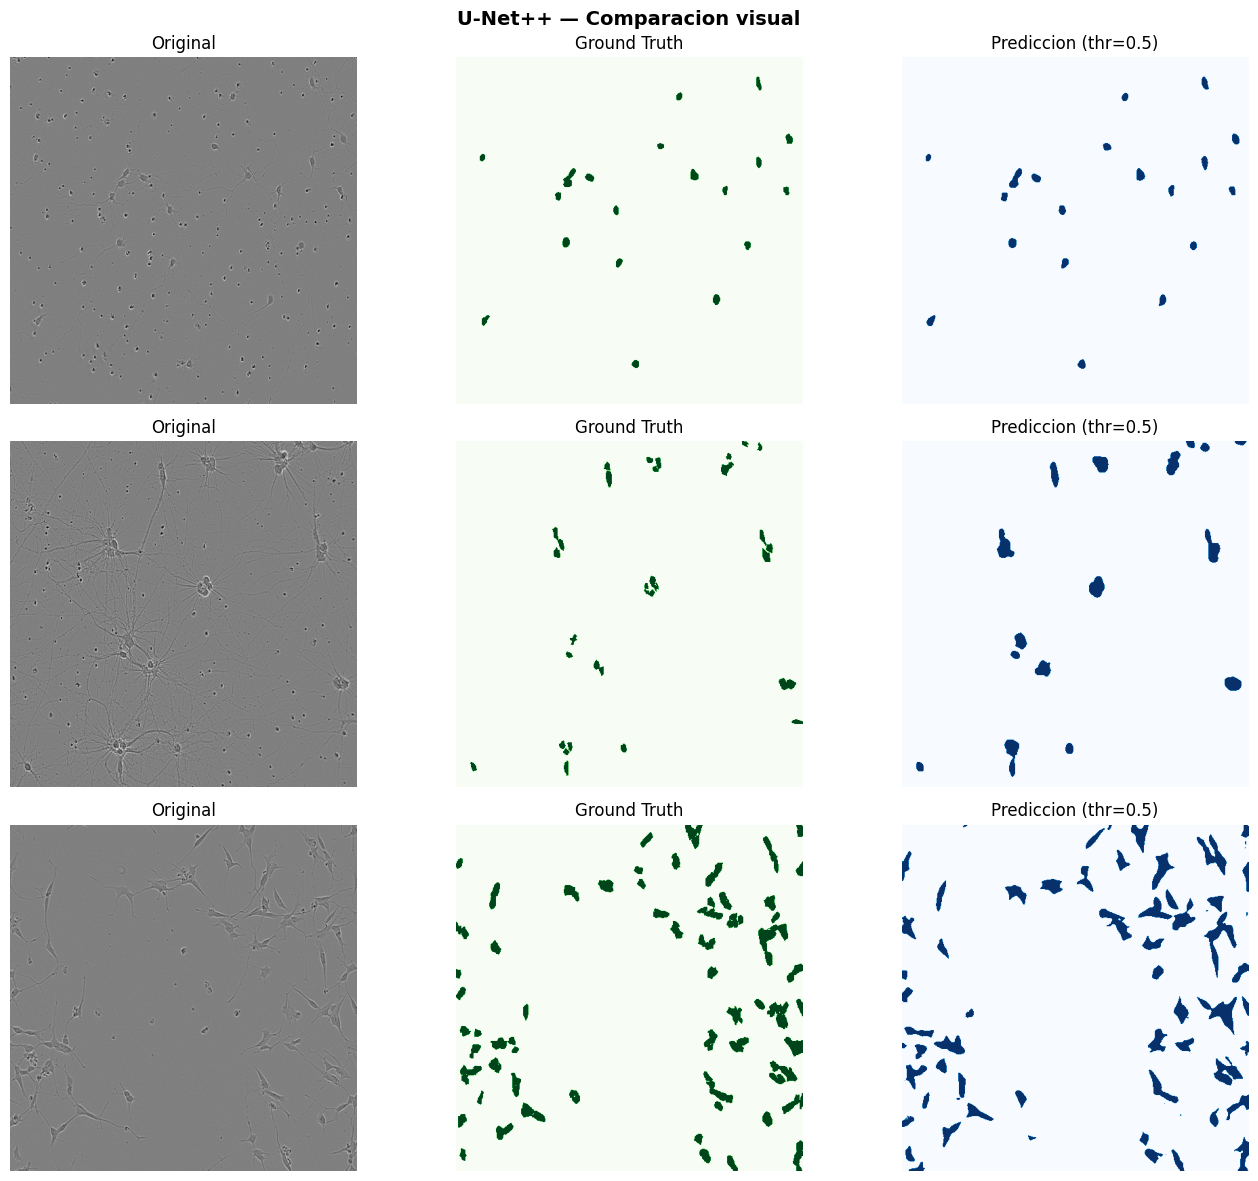

Guardado: evaluation_results\visual_u-net++.png


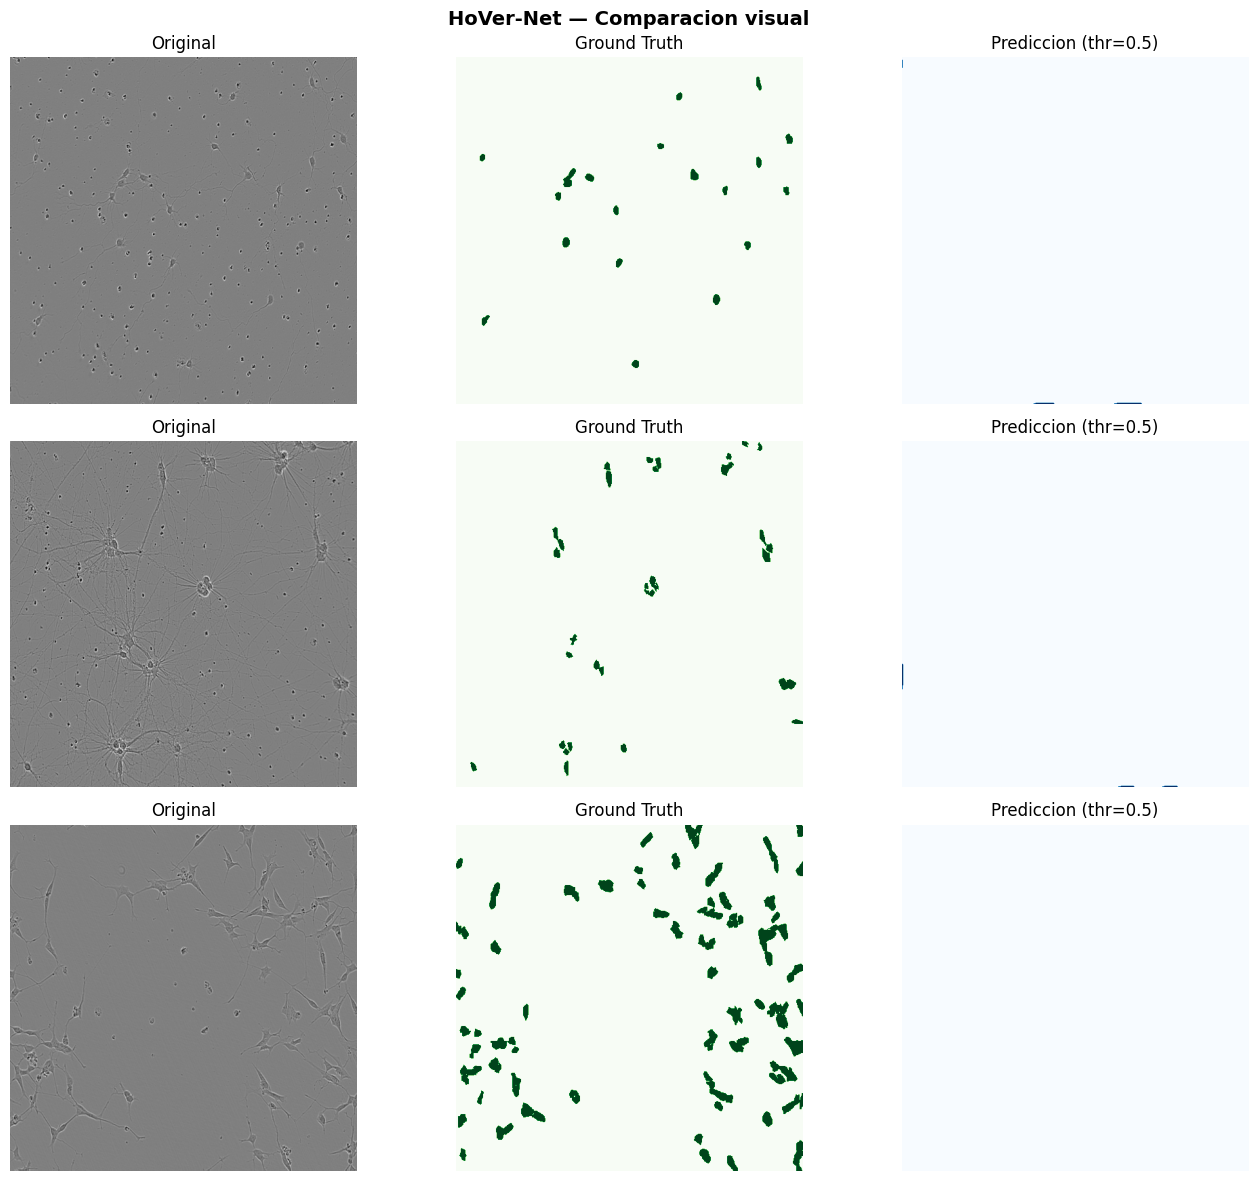

Guardado: evaluation_results\visual_hover-net.png


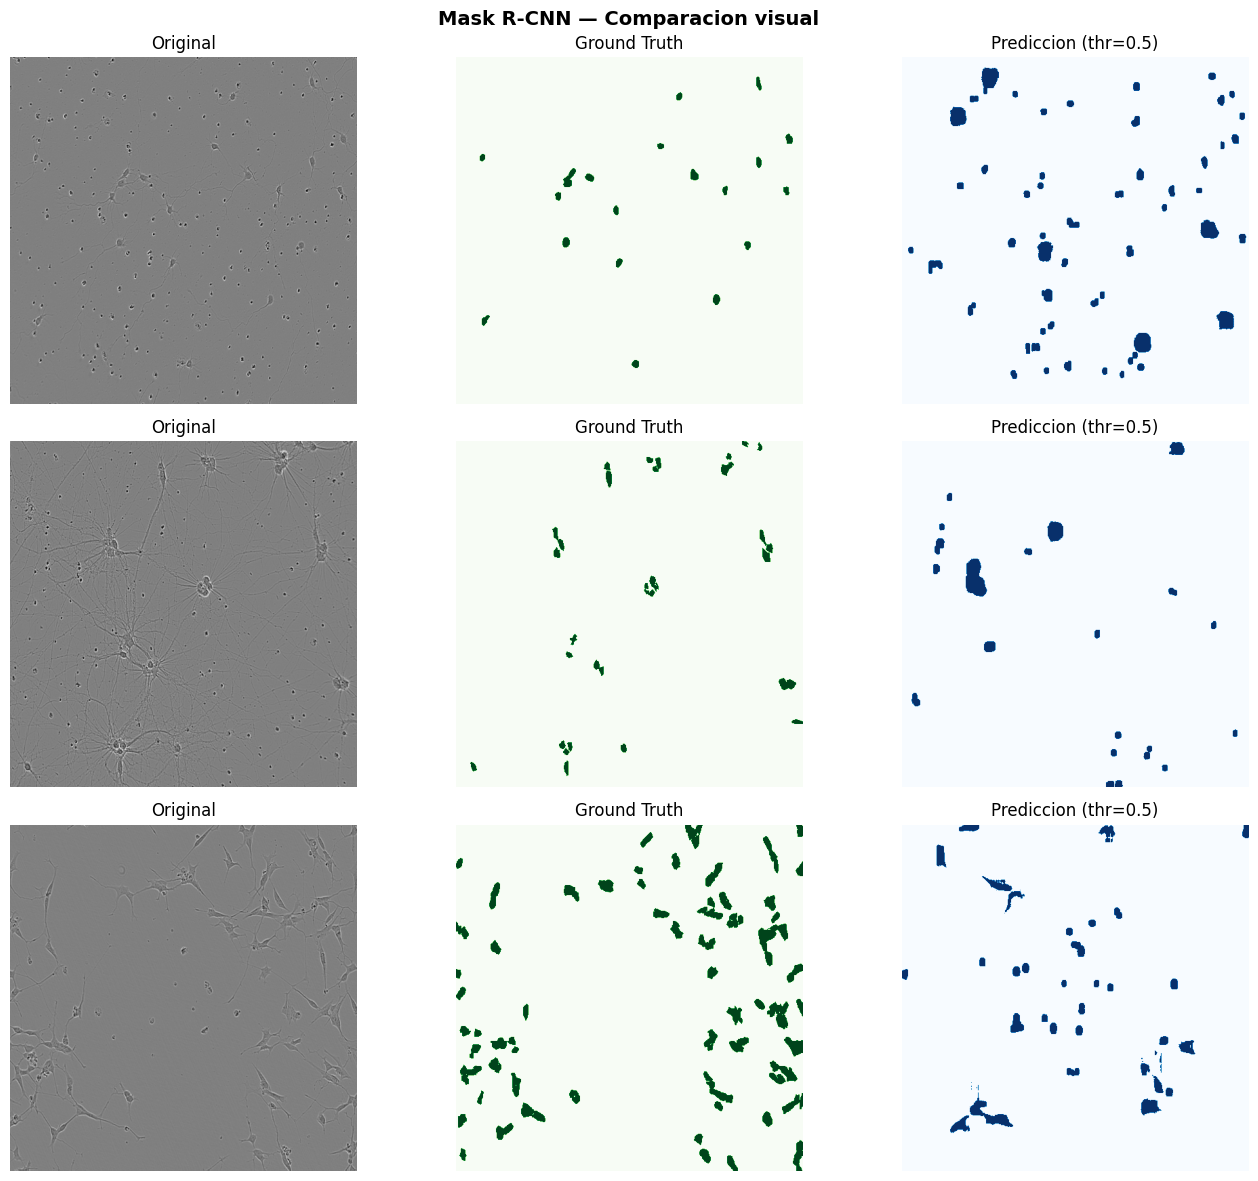

Guardado: evaluation_results\visual_mask_r-cnn.png


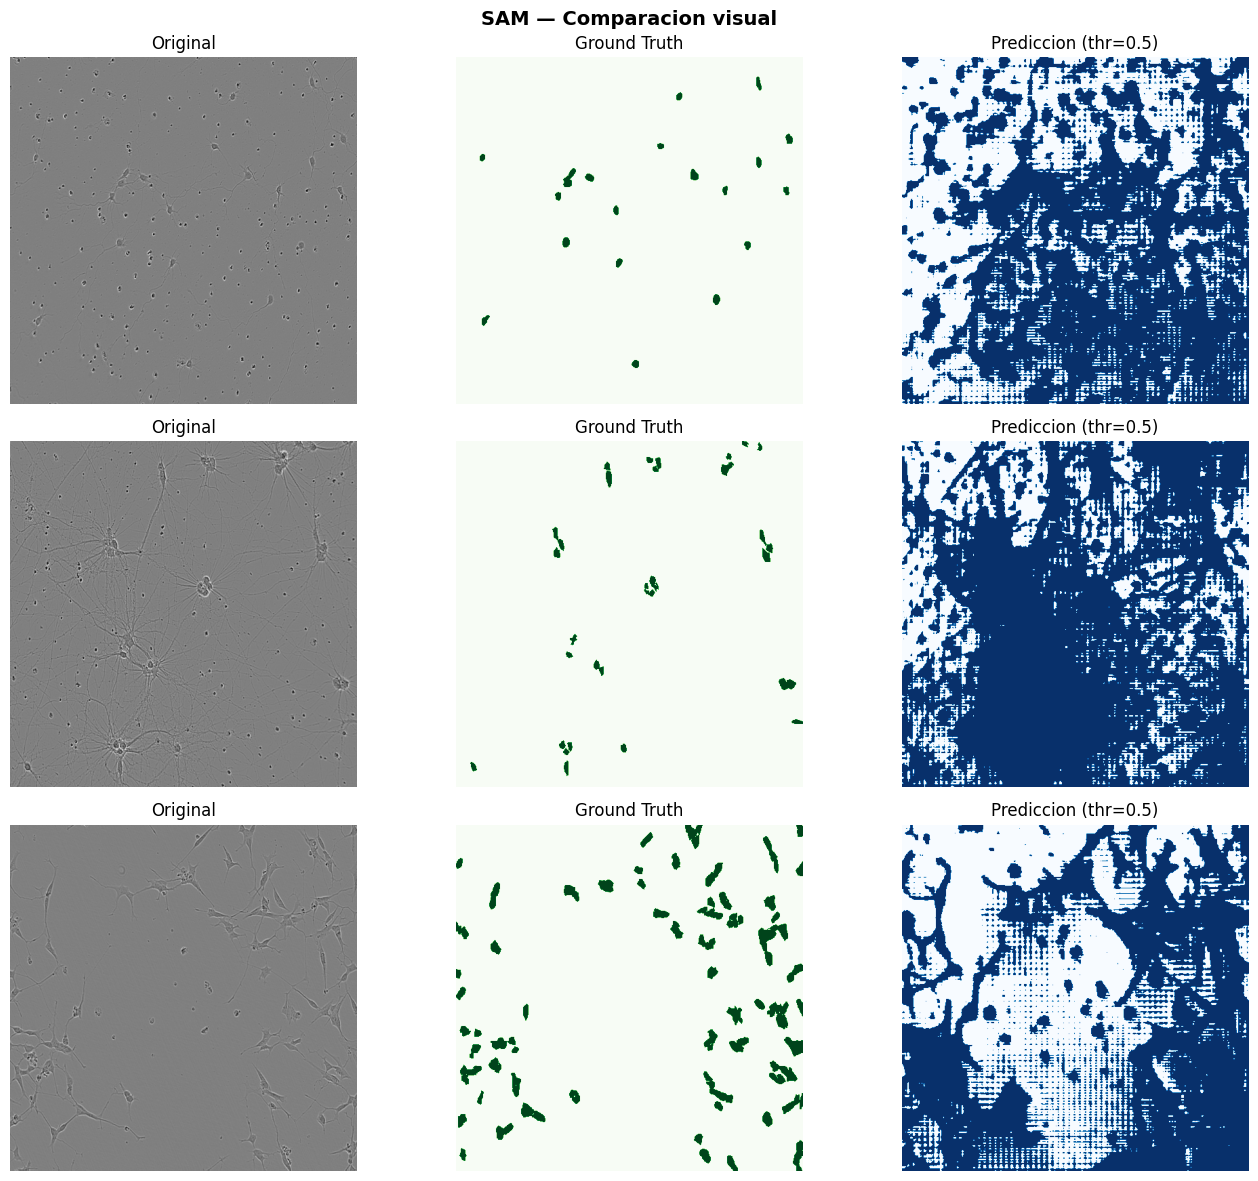

Guardado: evaluation_results\visual_sam.png


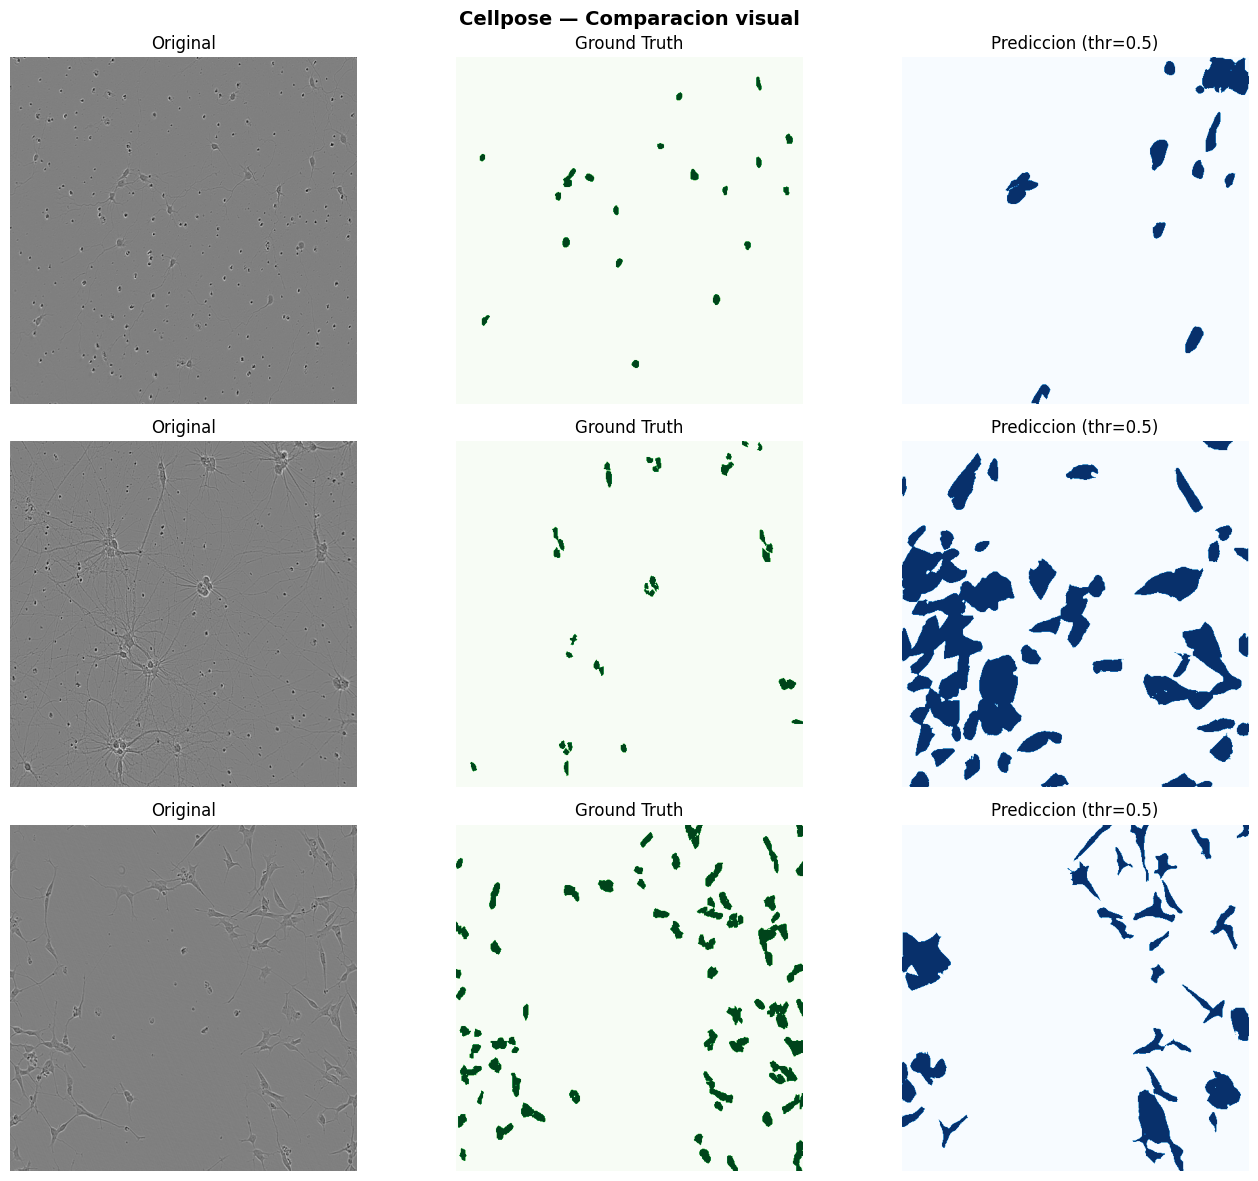

Guardado: evaluation_results\visual_cellpose.png


In [15]:
def visualize_predictions(model, model_name, df_sample, n=3,
                           is_hovernet=False, is_maskrcnn=False,
                           is_cellpose=False, is_sam=False,
                           threshold=0.5, device=DEVICE):
    # FIX #1: sin @torch.inference_mode() — interfiere con Cellpose
    # Para los demás modelos se aplica manualmente dentro del bloque

    fig, axes = plt.subplots(n, 3, figsize=(14, 4*n))
    fig.suptitle(f'{model_name} — Comparacion visual', fontsize=14,
                 fontweight='bold')

    sample = df_sample.sample(n, random_state=SEED)

    # FIX #1: solo llamar .eval() si NO es Cellpose
    if not is_cellpose:
        model.eval()

    for row_idx, (_, row) in enumerate(sample.iterrows()):

        result = preprocess(row['ruta_imagen'], row['rles'],
                            is_train=False)

        img_t  = result['image'].unsqueeze(0).to(device)
        masks  = result['masks']

        mean   = np.array([0.485, 0.456, 0.406])
        std    = np.array([0.229, 0.224, 0.225])
        img_np = result['image'].numpy().transpose(1, 2, 0)
        img_np = np.clip(img_np * std + mean, 0, 1)
        gt_bin = (masks.sum(0) > 0).numpy().astype(np.uint8)

        # ── Predicción por modelo ─────────────────────────────────────────
        if is_maskrcnn:
            with torch.inference_mode():
                preds = model([img_t.squeeze(0)])
            if len(preds[0]['masks']) == 0:
                pred_bin = np.zeros_like(gt_bin)
            else:
                pred_bin = (
                    preds[0]['masks'][:, 0].cpu().max(0).values > threshold
                ).numpy().astype(np.uint8)

        elif is_hovernet:
            with torch.inference_mode():
                np_out, _, _ = model(img_t)
            pred_bin = (
                torch.sigmoid(np_out).squeeze().cpu() > threshold
            ).numpy().astype(np.uint8)

        elif is_cellpose:
            img_cp = (img_np * 255).astype(np.uint8)
            masks_cp, *_ = model.eval(
                [img_cp],
                channels  = cp_hparams.get('chan', [0, 0]),   
                diameter  = cp_hparams.get('diameter', None),
                flow_threshold     = cp_hparams.get('flow_threshold', 0.4),
                cellprob_threshold = cp_hparams.get('cellprob_threshold', 0.0),
            )
            pred_bin = (masks_cp[0] > 0).astype(np.uint8)

        elif is_sam:
            from segment_anything import SamPredictor
            with torch.inference_mode():
                predictor = SamPredictor(model)
                img_uint8 = (img_np * 255).astype(np.uint8)
                predictor.set_image(img_uint8)
                y, x = np.where(gt_bin)
                if len(x) == 0 or len(y) == 0:
                    pred_bin = np.zeros_like(gt_bin)
                else:
                    box = np.array([x.min(), y.min(), x.max(), y.max()])
                    masks_sam, _, _ = predictor.predict(
                        box=box[None, :], multimask_output=False
                    )
                    pred_bin = masks_sam[0].astype(np.uint8)

        else:
            with torch.inference_mode():
                out = model(img_t)
            pred_bin = (
                torch.sigmoid(out).squeeze().cpu() > threshold
            ).numpy().astype(np.uint8)

        # ── Plot ──────────────────────────────────────────────────────────
        axes[row_idx, 0].imshow(img_np)
        axes[row_idx, 0].set_title('Original')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(gt_bin, cmap='Greens')
        axes[row_idx, 1].set_title('Ground Truth')
        axes[row_idx, 1].axis('off')

        axes[row_idx, 2].imshow(pred_bin, cmap='Blues')
        axes[row_idx, 2].set_title(f'Prediccion (thr={threshold})')
        axes[row_idx, 2].axis('off')

    plt.tight_layout()
    fname = OUTPUT_DIR / f'visual_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {fname}')
# ─────────────────────────────────────────────
# VISUALIZACIONES
# ─────────────────────────────────────────────

if model_up:
    visualize_predictions(
        model_up,
        'U-Net++',
        df_img,
        is_hovernet=False,
        is_maskrcnn=False
    )

if model_hv:
    visualize_predictions(
        model_hv,
        'HoVer-Net',
        df_img,
        is_hovernet=True,
        is_maskrcnn=False
    )

if model_mrcnn:
    visualize_predictions(
        model_mrcnn,
        'Mask R-CNN',
        df_img,
        is_maskrcnn=True
    )

if model_sam:
    visualize_predictions(
        model_sam,
        'SAM',
        df_img,
        is_sam=True
    )
if model_cp:
    visualize_predictions(
        model_cp,
        'Cellpose',
        df_img,
        is_cellpose=True
    )

## 11. Mapas de error

- **Rojo** → Falsos Positivos (FP): predicho como célula, es fondo
- **Azul** → Falsos Negativos (FN): es célula, no detectado

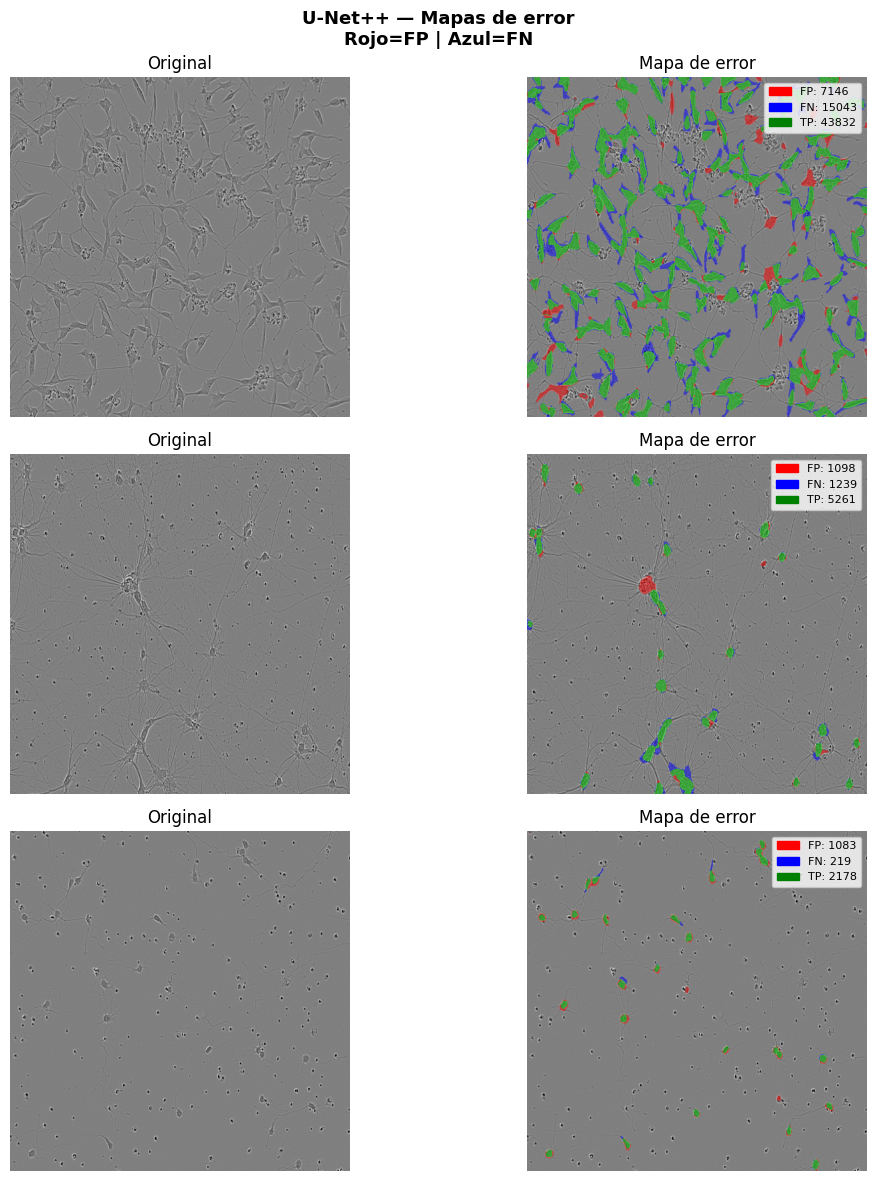

Guardado: evaluation_results\errors_u-net++.png


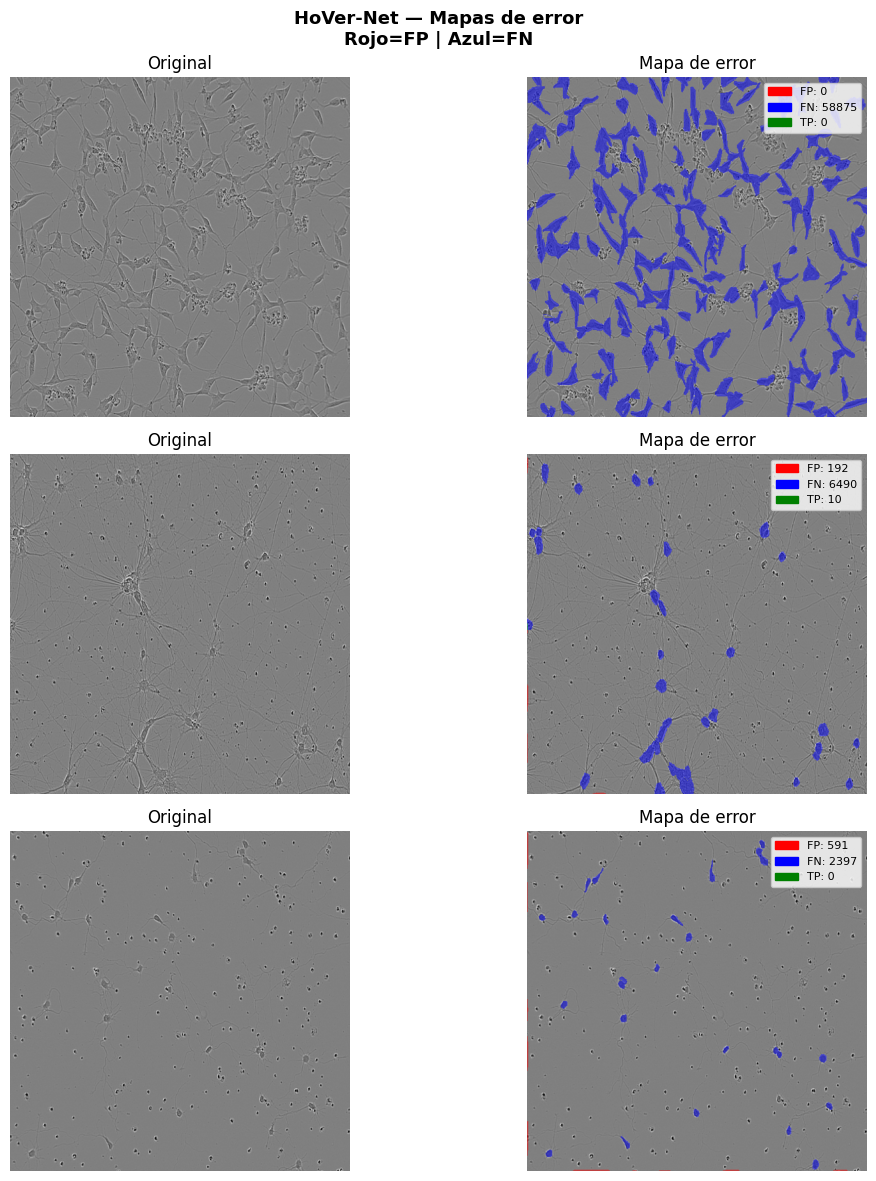

Guardado: evaluation_results\errors_hover-net.png


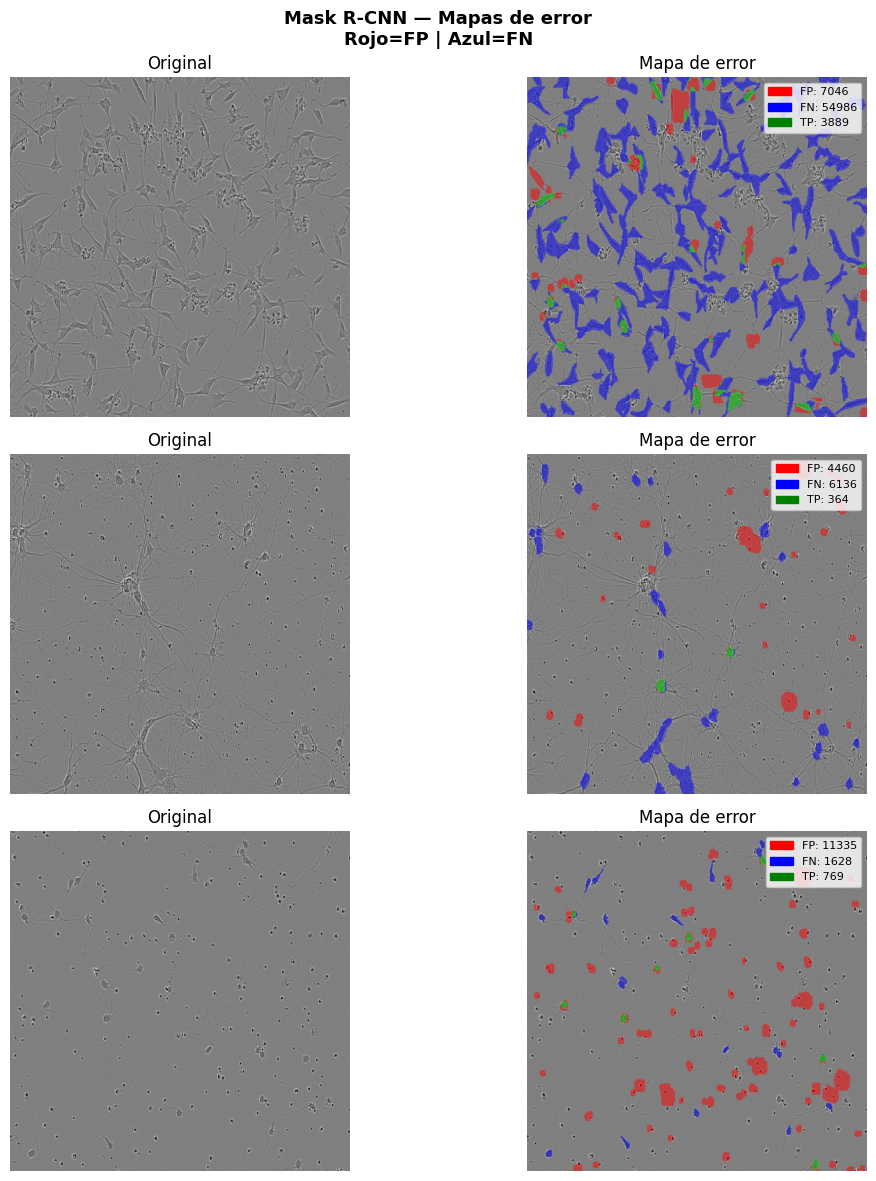

Guardado: evaluation_results\errors_mask_r-cnn.png


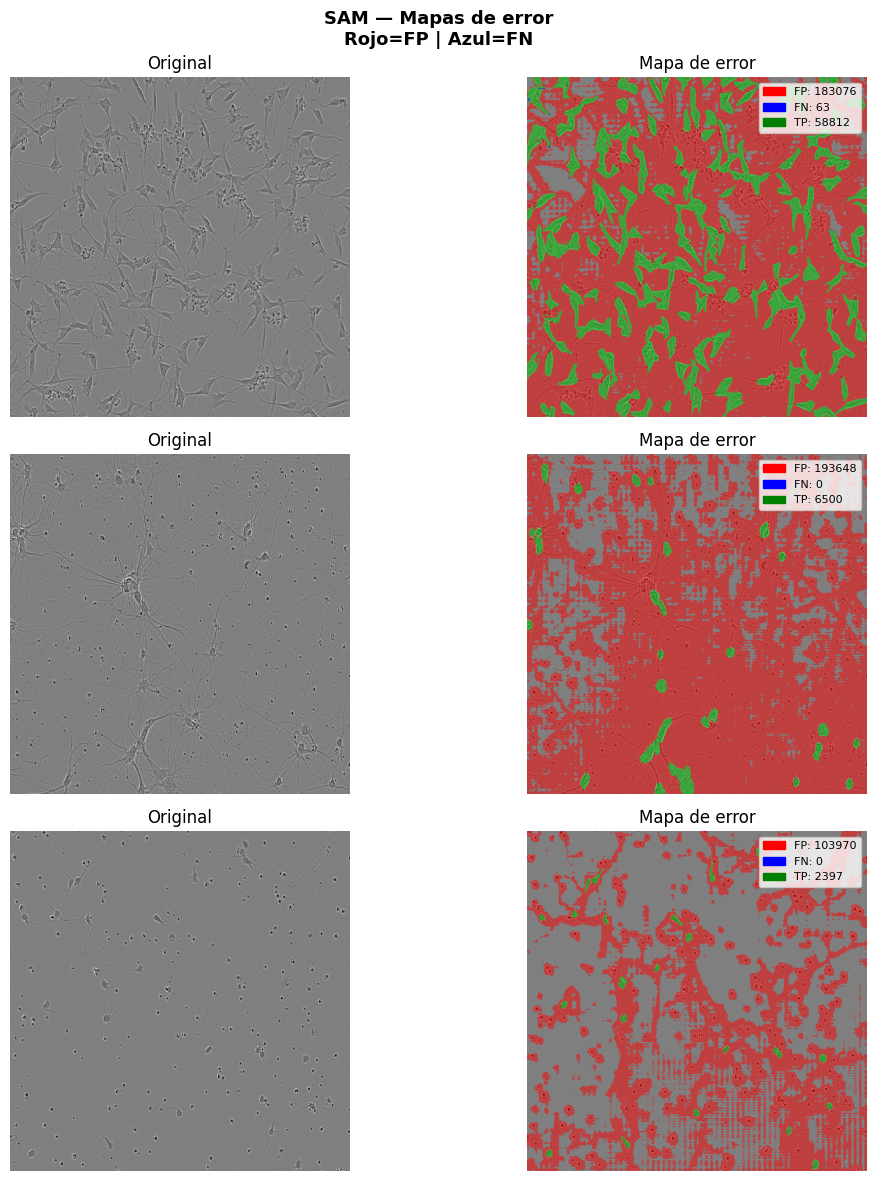

Guardado: evaluation_results\errors_sam.png


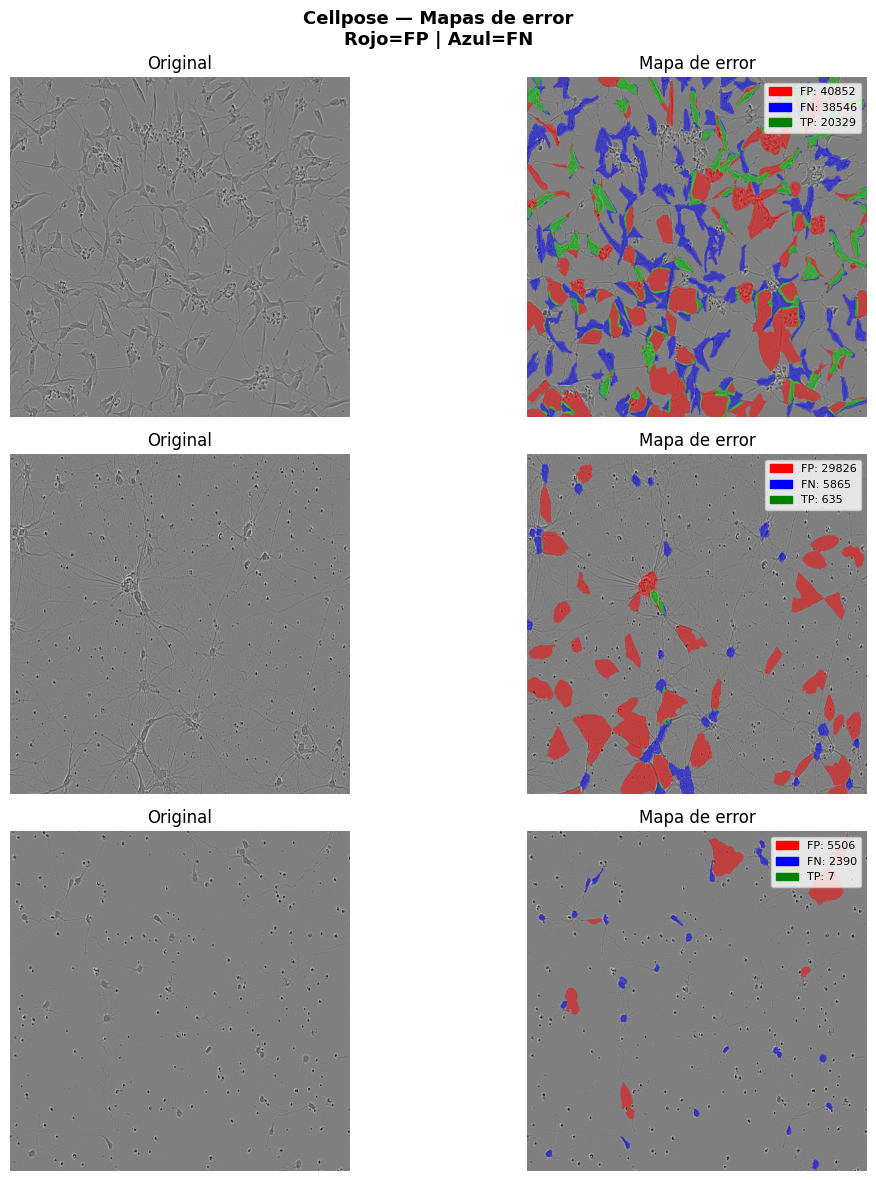

Guardado: evaluation_results\errors_cellpose.png


In [16]:
def plot_error_maps(model, model_name, df_sample, n=3,
                    is_hovernet=False, is_maskrcnn=False,
                    is_cellpose=False, is_sam=False,
                    threshold=0.5, device=DEVICE):
    # FIX #1: sin @torch.inference_mode()

    fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))
    fig.suptitle(f'{model_name} — Mapas de error\nRojo=FP | Azul=FN',
                 fontsize=13, fontweight='bold')

    sample = df_sample.sample(n, random_state=SEED + 1)

    # FIX #1: solo llamar .eval() si NO es Cellpose
    if not is_cellpose:
        model.eval()

    for row_idx, (_, row) in enumerate(sample.iterrows()):

        result = preprocess(row['ruta_imagen'], row['rles'],
                            is_train=False)

        img_t  = result['image'].unsqueeze(0).to(device)
        gt_bin = (result['masks'].sum(0) > 0).numpy().astype(bool)

        mean   = np.array([0.485, 0.456, 0.406])
        std    = np.array([0.229, 0.224, 0.225])
        img_np = np.clip(
            result['image'].numpy().transpose(1, 2, 0) * std + mean, 0, 1
        )

        # ── Predicción por modelo ─────────────────────────────────────────
        if is_maskrcnn:
            with torch.inference_mode():
                preds = model([img_t.squeeze(0)])
            if len(preds[0]['masks']) == 0:
                pred_bin = np.zeros_like(gt_bin)
            else:
                pred_bin = (
                    preds[0]['masks'][:, 0].cpu().max(0).values > threshold
                ).numpy().astype(bool)

        elif is_hovernet:
            with torch.inference_mode():
                np_out, _, _ = model(img_t)
            pred_bin = (
                torch.sigmoid(np_out).squeeze().cpu() > threshold
            ).numpy().astype(bool)

        elif is_cellpose:
            img_cp = (img_np * 255).astype(np.uint8)
            masks_cp, *_ = model.eval(
                [img_cp],
                channels  = cp_hparams.get('chan', [0, 0]),
                diameter  = cp_hparams.get('diameter', None),
                flow_threshold     = cp_hparams.get('flow_threshold', 0.4),
                cellprob_threshold = cp_hparams.get('cellprob_threshold', 0.0),
            )
            pred_bin = (masks_cp[0] > 0).astype(bool)

        elif is_sam:
            from segment_anything import SamPredictor
            with torch.inference_mode():
                predictor = SamPredictor(model)
                predictor.set_image((img_np * 255).astype(np.uint8))
                y, x = np.where(gt_bin)
                if len(x) == 0 or len(y) == 0:
                    pred_bin = np.zeros_like(gt_bin)
                else:
                    box = np.array([x.min(), y.min(), x.max(), y.max()])
                    masks_sam, _, _ = predictor.predict(
                        box=box[None, :], multimask_output=False
                    )
                    pred_bin = masks_sam[0].astype(bool)

        else:
            with torch.inference_mode():
                out = model(img_t)
            pred_bin = (
                torch.sigmoid(out).squeeze().cpu() > threshold
            ).numpy().astype(bool)

        # ── Mapa de error ─────────────────────────────────────────────────
        fp = pred_bin & ~gt_bin
        fn = ~pred_bin & gt_bin
        tp = pred_bin & gt_bin

        error_map          = np.zeros((*gt_bin.shape, 3), dtype=np.float32)
        error_map[tp]      = [0.0, 0.8, 0.0]
        error_map[fp]      = [1.0, 0.0, 0.0]
        error_map[fn]      = [0.0, 0.0, 1.0]
        overlay            = img_np.copy()
        mask_any           = fp | fn | tp
        overlay[mask_any]  = 0.5 * overlay[mask_any] + 0.5 * error_map[mask_any]

        fp_patch = mpatches.Patch(color='red',   label=f'FP: {fp.sum()}')
        fn_patch = mpatches.Patch(color='blue',  label=f'FN: {fn.sum()}')
        tp_patch = mpatches.Patch(color='green', label=f'TP: {tp.sum()}')

        axes[row_idx, 0].imshow(img_np)
        axes[row_idx, 0].set_title('Original')
        axes[row_idx, 0].axis('off')

        axes[row_idx, 1].imshow(overlay)
        axes[row_idx, 1].legend(
            handles=[fp_patch, fn_patch, tp_patch],
            loc='upper right', fontsize=8
        )
        axes[row_idx, 1].set_title('Mapa de error')
        axes[row_idx, 1].axis('off')

    plt.tight_layout()
    fname = OUTPUT_DIR / f'errors_{model_name.lower().replace(" ", "_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Guardado: {fname}')
# ─────────────────────────────────────────────
# ERROR MAPS
# ─────────────────────────────────────────────

if model_up:
    plot_error_maps(
        model_up,
        'U-Net++',
        df_img,
        is_hovernet=False,
        is_maskrcnn=False
    )

if model_hv:
    plot_error_maps(
        model_hv,
        'HoVer-Net',
        df_img,
        is_hovernet=True,
        is_maskrcnn=False
    )

if model_mrcnn:
    plot_error_maps(
        model_mrcnn,
        'Mask R-CNN',
        df_img,
        is_maskrcnn=True
    )
    
if model_sam:
    plot_error_maps(
        model_sam,
        'SAM',
        df_img,
        is_sam=True
    )
    
if model_cp:
    plot_error_maps(
        model_cp,
        'Cellpose',
        df_img,
        is_cellpose=True
    )

## 12. Curvas ROC y Precision-Recall

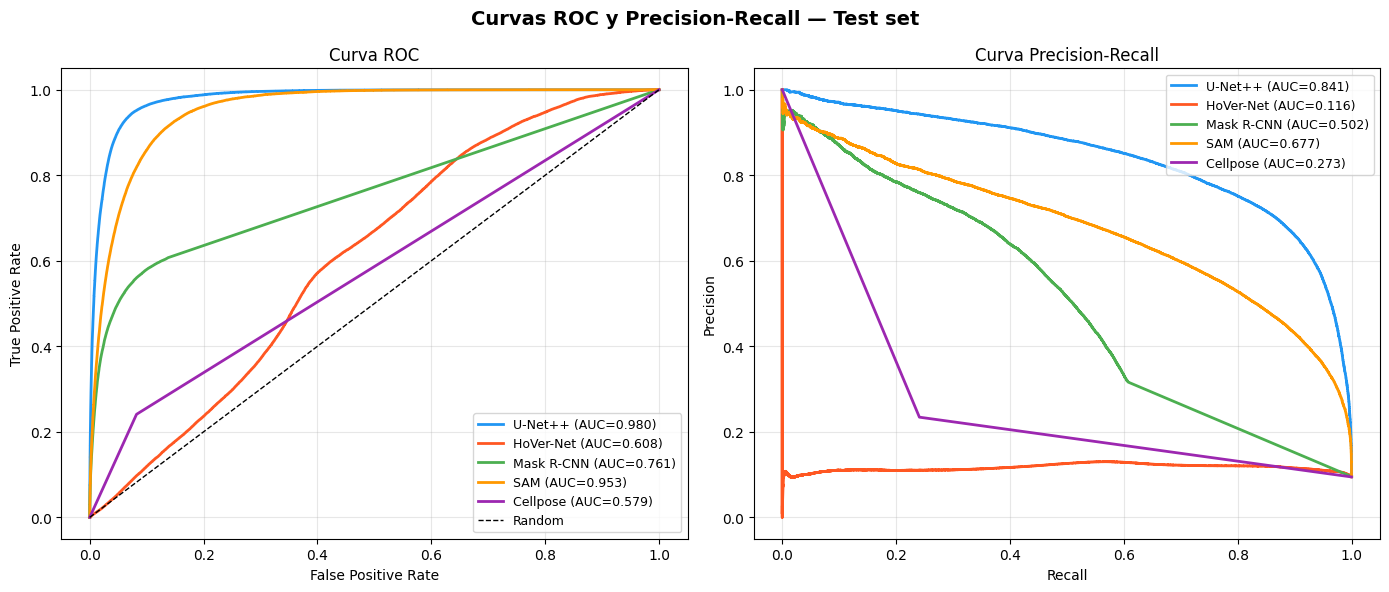

In [17]:
COLORS = {
    'unetpp'  : '#2196F3',
    'hovernet': '#FF5722',
    'maskrcnn': '#4CAF50',
    'cellpose': '#9C27B0',
    'sam'     : '#FF9800',
}
LABELS = {
    'unetpp'  : 'U-Net++',
    'hovernet': 'HoVer-Net',
    'maskrcnn': 'Mask R-CNN',
    'cellpose': 'Cellpose',
    'sam'     : 'SAM',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Curvas ROC y Precision-Recall — Test set',
             fontsize=14, fontweight='bold')

for name in test_probs:
    probs = test_probs[name]
    trues = test_trues[name]
    color = COLORS.get(name, 'gray')
    label = LABELS.get(name, name)

    # Sub-muestrear para velocidad (arrays muy grandes)
    if len(probs) > 500_000:
        idx   = np.random.choice(len(probs), 500_000, replace=False)
        probs_s = probs[idx]; trues_s = trues[idx]
    else:
        probs_s = probs; trues_s = trues

    if len(np.unique(trues_s)) < 2:
        continue

    # ROC
    fpr, tpr, _ = roc_curve(trues_s, probs_s)
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{label} (AUC={roc_auc_val:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(trues_s, probs_s)
    pr_auc_val   = auc(rec, prec)
    axes[1].plot(rec, prec, color=color, lw=2,
                 label=f'{label} (AUC={pr_auc_val:.3f})')

# ROC
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# PR
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Boxplots de métricas por modelo

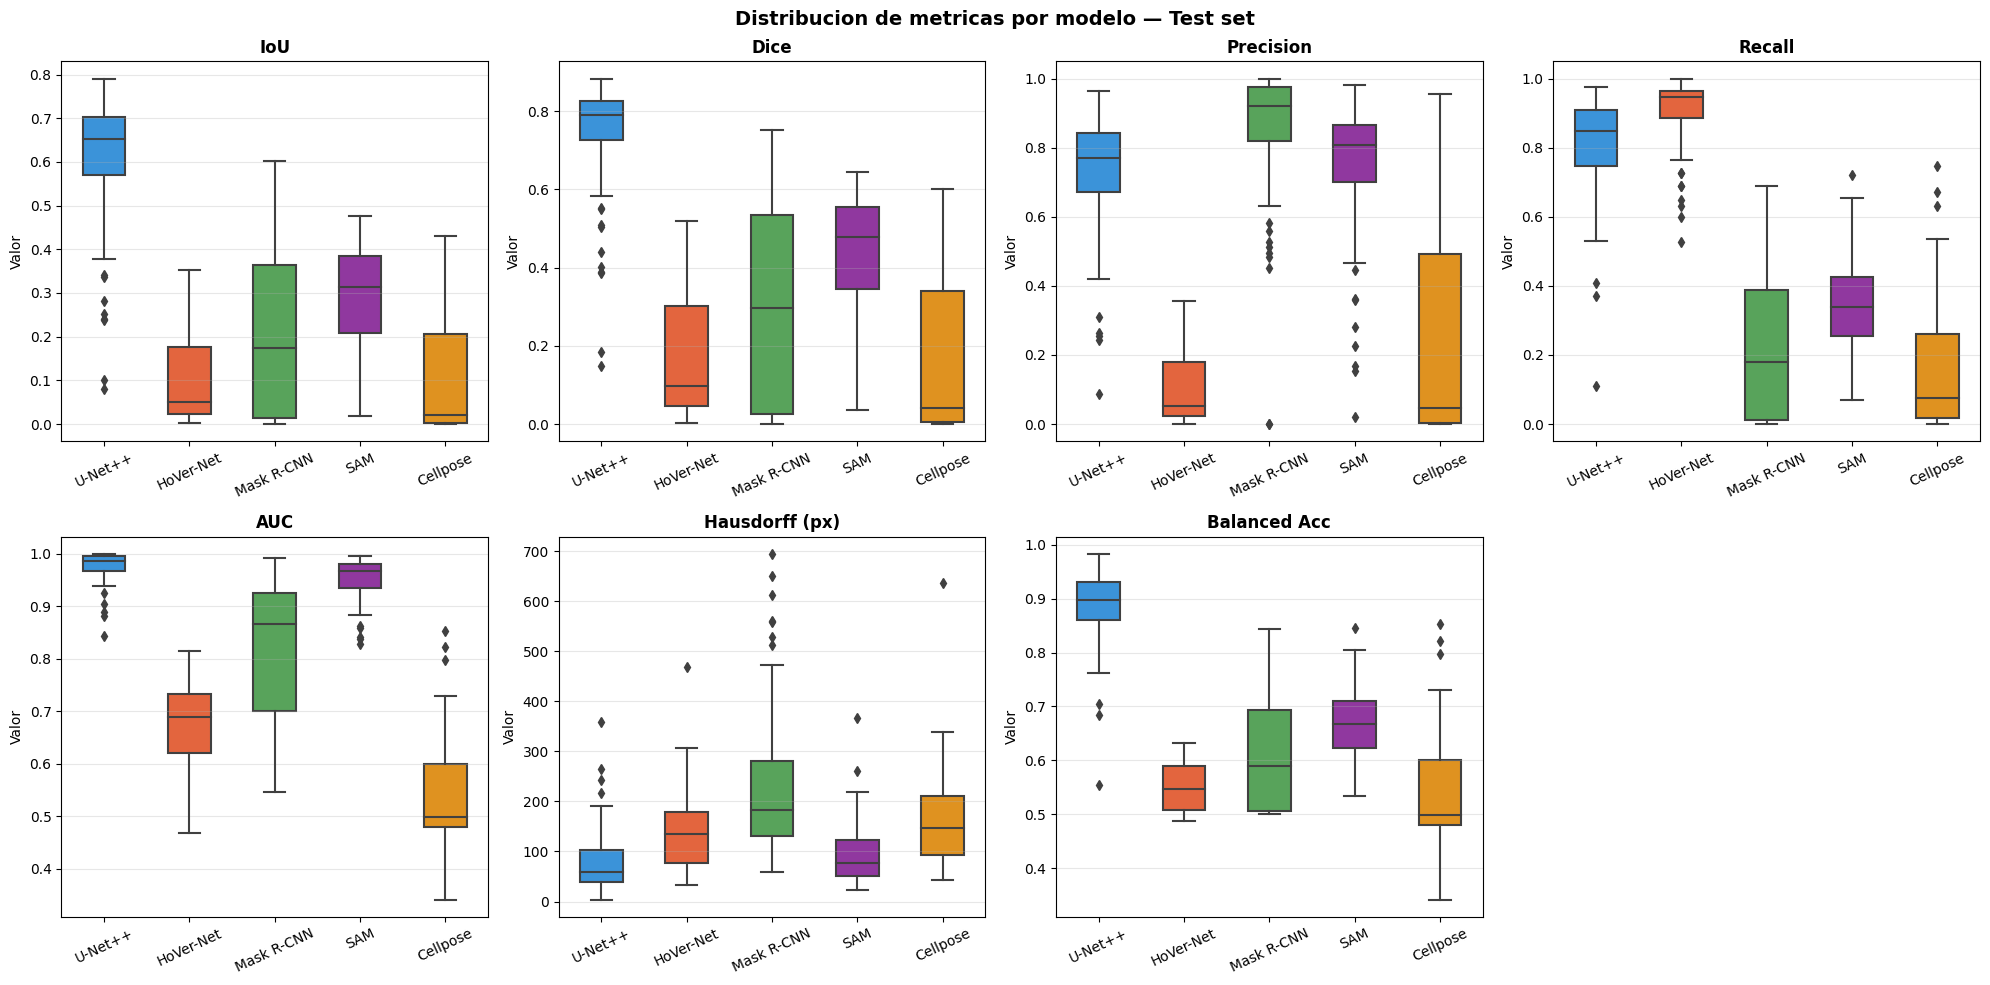

In [18]:
METRIC_NAMES = ['iou','dice','precision','recall',
                'auc','hausdorff','balanced_accuracy']
METRIC_LABELS = ['IoU','Dice','Precision','Recall',
                 'AUC','Hausdorff (px)','Balanced Acc']

# Construir DataFrame largo para seaborn
rows = []
for model_name, agg in test_results.items():
    raw = agg.get('raw', [])
    for r in raw:
        for mk in METRIC_NAMES:
            v = r.get(mk, np.nan)
            if v == float('inf'): v = np.nan
            rows.append({
                'Modelo' : LABELS.get(model_name, model_name),
                'Metrica': mk,
                'Valor'  : v
            })

df_long = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Distribucion de metricas por modelo — Test set',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

palette = list(COLORS.values())[:len(df_long['Modelo'].unique())]

for i, (mk, ml) in enumerate(zip(METRIC_NAMES, METRIC_LABELS)):
    ax  = axes_flat[i]
    sub = df_long[df_long['Metrica'] == mk]
    sns.boxplot(data=sub, x='Modelo', y='Valor',
                palette=palette, ax=ax, width=0.5)
    ax.set_title(ml, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(True, alpha=0.3, axis='y')

axes_flat[-1].set_visible(False)  # 7 metricas en 8 subplots
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'boxplots_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Histogramas de distribución de métricas

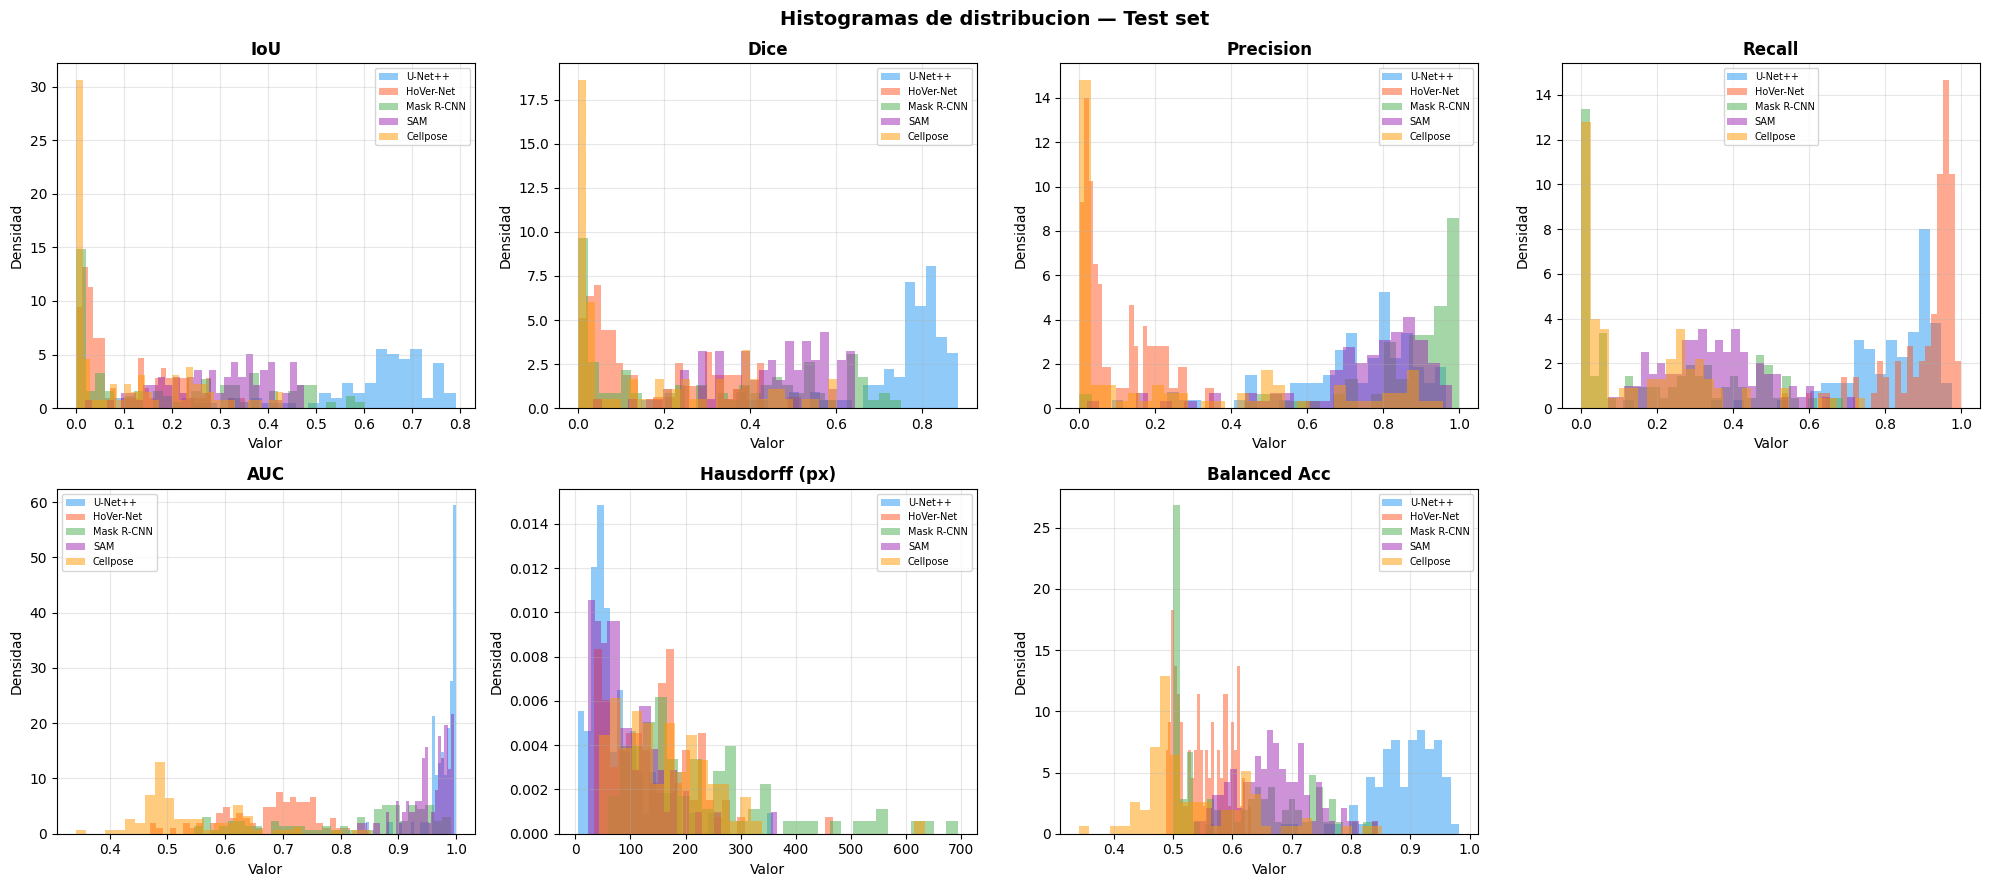

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('Histogramas de distribucion — Test set',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, (mk, ml) in enumerate(zip(METRIC_NAMES, METRIC_LABELS)):
    ax = axes_flat[i]
    for j, (model_name, agg) in enumerate(test_results.items()):
        raw  = agg.get('raw', [])
        vals = [r.get(mk, np.nan) for r in raw
                if r.get(mk, np.nan) != float('inf')
                and not np.isnan(r.get(mk, np.nan))]
        if not vals:
            continue
        ax.hist(vals, bins=30, alpha=0.5,
                color=list(COLORS.values())[j],
                label=LABELS.get(model_name, model_name),
                density=True)
    ax.set_title(ml, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes_flat[-1].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'histogramas_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Tabla comparativa final

In [21]:
# ── Test ─────────────────────────────────────────────────────
print('\n' + '='*70)
print('RESULTADOS FINALES — TEST SET')
print('='*70)

rows_test = []
for model_name, agg in test_results.items():
    row = {'Modelo': LABELS.get(model_name, model_name)}
    for mk in METRIC_NAMES:
        if mk in agg:
            row[mk] = f'{agg[mk]["mean"]:.4f}±{agg[mk]["std"]:.4f}'
    rows_test.append(row)

df_test_summary = pd.DataFrame(rows_test).set_index('Modelo')
df_test_summary.columns = METRIC_LABELS
print(df_test_summary.to_string())

# ── K-Fold ───────────────────────────────────────────────────
print('\n' + '='*70)
print('RESULTADOS FINALES — K-FOLD (k=5)')
print('='*70)

rows_kf = []
all_kfold_models = [k.replace('_summary','')
                    for k in kfold_results if k.endswith('_summary')]
for model_name in all_kfold_models:
    key = f'{model_name}_summary'
    if key not in kfold_results:
        continue
    summ = kfold_results[key]
    row  = {'Modelo': LABELS.get(model_name, model_name)}
    for mk in METRIC_NAMES:
        if mk in summ:
            row[mk] = f'{summ[mk]["mean"]:.4f}±{summ[mk]["std"]:.4f}'
    rows_kf.append(row)

if rows_kf:
    df_kf_summary = pd.DataFrame(rows_kf).set_index('Modelo')
    df_kf_summary = df_kf_summary.reindex(columns=METRIC_NAMES)
    print(df_kf_summary.to_string())

# ── Guardar JSON ─────────────────────────────────────────────
final_results = {
    'test'  : {
        k: {mk: {'mean': float(v['mean']), 'std': float(v['std'])}
            for mk, v in agg.items() if mk != 'raw'}
        for k, agg in test_results.items()
    },
    'kfold' : {
        k.replace('_summary',''): v
        for k, v in kfold_results.items() if 'summary' in k
    }
}
with open(OUTPUT_DIR / 'final_results.json', 'w') as f:
    json.dump(final_results, f, indent=2, default=float)

print(f'\nResultados guardados en {OUTPUT_DIR}/final_results.json')
print('\nArchivos generados:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name}')


RESULTADOS FINALES — TEST SET
                      IoU           Dice      Precision         Recall            AUC     Hausdorff (px)   Balanced Acc
Modelo                                                                                                                 
U-Net++     0.6103±0.1473  0.7453±0.1400  0.7261±0.1724  0.8110±0.1366  0.9779±0.0267    79.5583±62.9064  0.8861±0.0645
HoVer-Net   0.0997±0.0917  0.1693±0.1444  0.1006±0.0928  0.9060±0.0955  0.6742±0.0767   138.3294±75.3747  0.5502±0.0418
Mask R-CNN  0.2022±0.1867  0.2973±0.2535  0.8552±0.1863  0.2160±0.2027  0.8165±0.1325  230.6393±140.0266  0.6076±0.1012
SAM         0.2972±0.1075  0.4471±0.1341  0.7458±0.1912  0.3465±0.1324  0.9521±0.0386    91.7753±57.7645  0.6670±0.0634
Cellpose    0.1054±0.1240  0.1698±0.1878  0.2575±0.3169  0.1590±0.1706  0.5375±0.0920   159.9363±88.5814  0.5375±0.0920

RESULTADOS FINALES — K-FOLD (k=5)
                      iou           dice      precision         recall            auc        h